# DNAI

<div style="
    background-color: #e7f3ff;
    border-left:6px solid #2196f3;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>⚠️ Warning</strong><br>
This notebook assumes the project environment is installed.
Run:
<pre><code>import sys
!"{sys.executable}" -m pip install -e ..</code></pre>
Restart the kernel before continuing.
</div>

In [1]:
# import sys
# !"{sys.executable}" -m pip install -e ..

* Load modules and directories

In [1]:
from DNAI.utils.paths import DATA_RAW_DIR, RESULTS_DIR, RESULTS_FIGURES_DIR, RESULTS_TABLES_DIR
from DNAI.features import engineering 
from DNAI.features import transcript_analysis

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Analysts

In [2]:
df_analysts = pd.read_excel(f'{DATA_RAW_DIR}/Dados Analistas/Analistas - Empilhada - Tratada e Limpa V02.xlsx', sheet_name='Dados Empilhados')

* Separate data for the two analysts

In [3]:
df_analysts_sv = df_analysts[df_analysts['A.01b - Analista'] == 'SV'].copy()
df_analysts_vs = df_analysts[df_analysts['A.01b - Analista'] == 'VS'].copy()

1. Duplicate and missing data detection

In [4]:
for (analyst, df) in [('SV',df_analysts_sv), ('VS',df_analysts_vs)]:
    print(f'Duplicated {analyst} : {df['ID e Nome do Filme'].duplicated().sum()}')
    print(f'Missing {analyst} : {df['ID e Nome do Filme'].isna().sum()}')

Duplicated SV : 0
Missing SV : 0
Duplicated VS : 0
Missing VS : 0


2. Film ID extraction

In [5]:
column = 'ID Filme Novo'

df_analysts_sv['film_id'] = df_analysts_sv[column]
df_analysts_vs['film_id'] = df_analysts_vs[column]

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [6]:
df_analysts_sv = df_analysts_sv[df_analysts_sv['film_id'] > 1069000]
df_analysts_vs = df_analysts_vs[df_analysts_vs['film_id'] > 1069000]

3. Theme 1 extraction

In [7]:
column = 'C.01c - Primeiro Tema'

df_analysts_sv['category_SV'] = df_analysts_sv[column].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()
df_analysts_vs['category_VS'] = df_analysts_vs[column].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

C:\Users\User01\AppData\Local\Temp\ipykernel_57416\1150851148.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysts_vs['category_VS'] = df_analysts_vs[column].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()


### IRR

* Combine first themes from both analysts

In [8]:
df_merge_analysts = pd.merge(df_analysts_sv[['film_id', 'category_SV']], df_analysts_vs[['film_id', 'category_VS']], on='film_id')

* Compute Cohen's kappa, Krippendorff's alpha and Fleiss's kappa (optional)

In [9]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(df_merge_analysts["category_SV"], df_merge_analysts["category_VS"])
print("Cohen's kappa:", kappa)

Cohen's kappa: 0.29570784918188286


In [10]:
import krippendorff

df_num = engineering.cat_to_numeric(df_merge_analysts)

alpha_analysts = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')
print("Krippendorff alpha:", alpha_analysts)


Krippendorff alpha: 0.08448825657693015


* Note: Krippendorff's alpha value is low, there is low agreement between analysts. Exploratory Data Analysis will be made to investigate reasons for disagreement

In [11]:
# from statsmodels.stats.inter_rater import fleiss_kappa

# M = np.zeros((len(df_merge_analysts), len(cats)), dtype=int)

# for i, (_, row) in enumerate(df_merge_analysts.iterrows()):
#     for r in [row["category_SV"], row["category_VS"]]:
#         M[i, np.where(cats == r)] += 1

# kappa = fleiss_kappa(M)
# print("Fleiss' kappa:", kappa)

### EDA

1. Category frequency

In [12]:
df_merge_analysts

,film_id,category_SV,category_VS
0,1070101,gênero e sexualidade,violência
1,1070102,vida afetiva,dinâmica urbana
2,1070103,vida afetiva,vida afetiva
3,1070105,família,saúde mental
4,1070106,família,gênero e sexualidade
...,...,...,...
145,1110322,cultural,cultural
146,1110323,cultural,cultural
147,1110324,família,"recreação, lazer e entretenimento"
148,1110325,outros,saúde mental


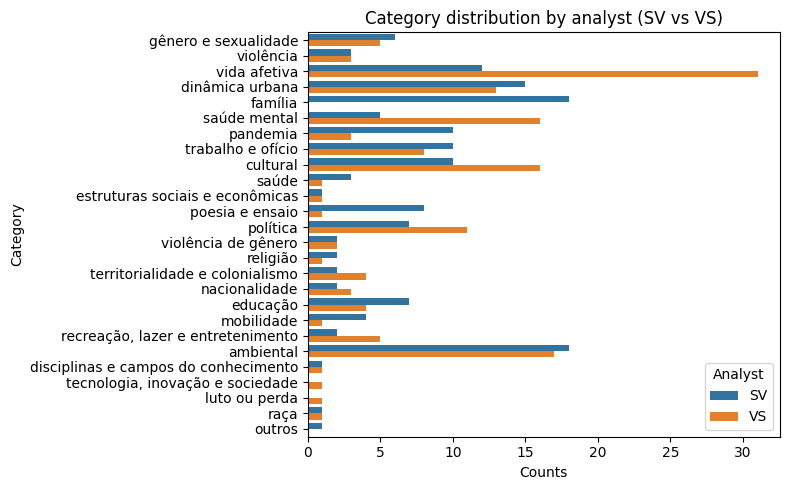

In [13]:
cats = pd.unique(df_merge_analysts[['category_SV', 'category_VS']].values.ravel())

# Dataframe inlong format for easier plotting
df_long = pd.melt(
    df_merge_analysts,
    value_vars=['category_SV', 'category_VS'],
    var_name='Analyst',
    value_name='Category'
)

# Make the order consistent
rater_labels = {'category_SV': 'SV', 'category_VS': 'VS'}
df_long['Analyst'] = df_long['Analyst'].map(rater_labels)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_long,
    y='Category',
    hue='Analyst',
    order=cats,      # ensures consistent category order
)

plt.title("Category distribution by analyst (SV vs VS)")
plt.xlabel("Counts")
plt.ylabel("Category")
plt.legend(title='Analyst')
plt.tight_layout()

plt.savefig(f'{RESULTS_FIGURES_DIR}/categories_analysts.png', dpi = 300)
plt.show()


* Note: There are categories with high disparity between analysts, such as cultural, família, saúde mental and vida afetiva.

2. Confusion matrix

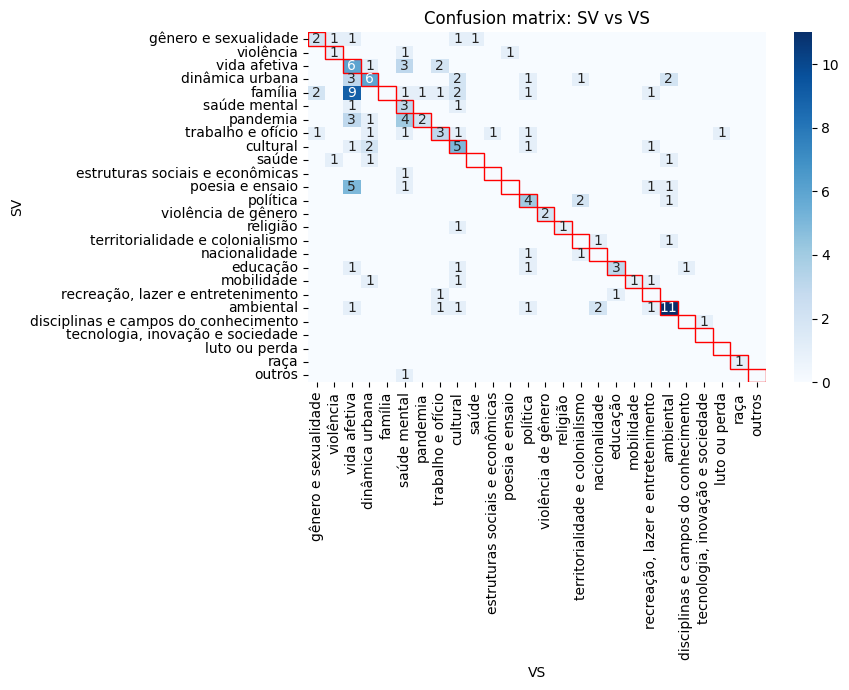

In [14]:
df = df_merge_analysts.copy()

df['category_SV'] = pd.Categorical(df['category_SV'], categories=cats)
df['category_VS'] = pd.Categorical(df['category_VS'], categories=cats)

ct = pd.crosstab(df['category_SV'], df['category_VS'], dropna=False)

# Create a mask of zeros
mask_zeros = ct == 0

# Convert zeros to empty strings for annotation
annot_data = ct.astype(str)
annot_data[mask_zeros] = ""

fig, ax = plt.subplots(1,1, figsize=(9,7))
sns.heatmap(ct, annot=annot_data, cmap="Blues", fmt="", ax = ax)

# Draw boxes around diagonal elements
for i in range(len(ct)):
    # x, y coordinates are (col, row)
    rect = plt.Rectangle(
        (i, i),              # (x, y)
        1, 1,                # width, height (one cell)
        fill=False,          # no fill
        edgecolor='red',     # box color
        linewidth=1
    )
    ax.add_patch(rect)
ax.set_title("Confusion matrix: SV vs VS")
ax.set_ylabel('SV')
ax.set_xlabel('VS')
# Force matplotlib to show all tick labels
ax.set_yticks(np.arange(len(ct.index)) + 0.5)   # +0.5 centers labels in cells
ax.set_yticklabels(ct.index, rotation=0)        # or rotation=0 for horizontal

ax.set_xticks(np.arange(len(ct.columns)) + 0.5)
ax.set_xticklabels(ct.columns, )
plt.tight_layout()
plt.savefig(f'{RESULTS_FIGURES_DIR}/confusion_matrix_analysts.png', dpi= 300)
plt.show()

* Note : There is higher agreement for categories ambiente, cultural, dinâmica urbana, gênero e sexualidade, saúde mental e vida afetiva.
* Note: There is higher disagreement between família (SV) and vida afetiva (VS); poesia e ensaio (SV) and vida afetiva (VS)  

In [15]:
df['agree'] = df['category_VS'] == df['category_SV']

print(f"Agreement ration: {round(df['agree'].mean()*100,2)} %")

Agreement ration: 34.0 %


## Authors and Peers

In [16]:
df_authors_peers = pd.read_excel(f'{DATA_RAW_DIR}/Dados Autores e Pares/Dados Empilhados Categorizados Limpos Autores e Pares Padronizados V03.xlsx')

1. Film ID extraction

In [17]:
df_authors_peers['film_id'] = df_authors_peers['IDFIlmes1']

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [18]:
df_authors_peers = df_authors_peers[df_authors_peers['film_id'] > 1069000]

2. Theme 1 extraction

In [19]:
df_authors_peers['category'] = df_authors_peers['Tema 1'].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

3. Pivot of authors and peers

In [20]:
column_status = '2014b_Status_Participante_Filme'

df_authors = df_authors_peers[df_authors_peers[column_status] == 'Participou'].copy()
df_peers = df_authors_peers[df_authors_peers[column_status] == 'Não Participou'].copy()

df_authors = df_authors[['film_id', 'category']]
df_peers = df_peers[['film_id', 'category']]

df_authors['rater_index'] = df_authors.groupby('film_id').cumcount() + 1
df_peers['rater_index'] = df_peers.groupby('film_id').cumcount() + 1

In [21]:
df_authors_wide = (df_authors.pivot(index='film_id', columns='rater_index', values='category').sort_index(axis=1))
df_authors_wide.columns = [f'category_{idx}' for idx in df_authors_wide.columns]

df_peers_wide = (df_peers.pivot(index='film_id', columns='rater_index', values='category').sort_index(axis=1))
df_peers_wide.columns = [f'category_{idx}' for idx in df_peers_wide.columns]

### IRR

1. Authors

In [22]:
df_num = engineering.cat_to_numeric(df_authors_wide)

alpha_authors = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')

print("Krippendorff’s alpha:", alpha_authors)

Krippendorff’s alpha: 0.2862814782343226


2. Peers

In [23]:
df_num = engineering.cat_to_numeric(df_peers_wide)

alpha_peers = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')

print("Krippendorff’s alpha:", alpha_peers)

Krippendorff’s alpha: 0.249802561065808


## AI

### ChatGPT

In [24]:
df_ai_chatgpt = pd.read_excel(f'{DATA_RAW_DIR}/Dados IA/AN-IA - SV_ChatGPT_ Formulário de simulação de análise e categorização de filmes por IA (respostas).xlsx')

1. Duplicate and missing data removal

In [25]:
column = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_ai_chatgpt.drop_duplicates(subset=column, keep='first', inplace=True)
df_ai_chatgpt.dropna(subset=column, inplace=True)

2. Film ID extraction

In [26]:
df_ai_chatgpt['film_id'] = df_ai_chatgpt[column].str.extract(r"\)\s*(.*?)\s*-").astype(int)

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [27]:
df_ai_chatgpt = df_ai_chatgpt[df_ai_chatgpt['film_id'] > 1069000]

In [28]:
df_titles = df_ai_chatgpt[[column, 'film_id']].copy()
df_titles['title'] =df_titles[column].str.extract(r"-\s*(.+?)\s*-")

3. Theme 1 extraction

In [29]:
pattern = r'''(?isx)
^
(?:\s*(?:Categoria\s*[A-Z]\s*[-–—]\s*|[A-Z][\.\)]\s*|[A-Z]\s*[–—]\s*))?   # optional prefix
\s*
(.+?)                                                                      # capture main category
(?=                                                                        # stop before optional suffix or end
    \s*
    (?:[-–—]?\s*(?:sub(?:categoria)?\b.*|\(principal\))\s*)?
    $
)
'''

column = 'E.2a) 1 - Categorias/Temas centrais - principal (primeira)'

df_ai_chatgpt['category'] = (df_ai_chatgpt[column].str 
    .extract(pattern, expand=False)
    .str.strip()
    .replace("", pd.NA)
)

df_ai_chatgpt['category']

18           Diversidade, Gênero e Sociedade
19                    Drama Urbano em Lisboa
20                      Poética do Cotidiano
21                Memória & Laços Familiares
22     Género, Trabalho Doméstico e Pandemia
                       ...                  
164     Ficção & Fantasia Contemporânea (BR)
165           Media Literacy & Desinformação
166      Memória, Resistência e Universidade
167           Processos de Dança & Making-of
168                Eco-ficções & Antropoceno
Name: category, Length: 149, dtype: object

* removal of "(principal)" if it persists

In [30]:
df_ai_chatgpt["category"] = df_ai_chatgpt["category"].str.replace(r"\s*\(principal\)\s*$", "", regex=True).str.strip()

### Gemini

In [31]:
df_ai_gemini = pd.read_excel(f'{DATA_RAW_DIR}/Dados IA/AN-IA - VS_Gemini_ Formulário de simulação de análise e categorização de filmes por IA (respostas) (1).xlsx')

1. Duplicate and missing data removal

In [32]:
column = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_ai_gemini.drop_duplicates(subset=column, keep='first', inplace=True)
df_ai_gemini.dropna(subset=column, inplace=True)

2. Film ID extraction

In [33]:
df_ai_gemini['film_id'] = df_ai_gemini['D.01 - Qual o filme referente a esta análise simulada de IA?'].str.extract(r"\)\s*(.*?)\s*-").astype(int)

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [34]:
df_ai_gemini = df_ai_gemini[df_ai_gemini['film_id'] > 1069000]

3. Theme 1 extraction

In [35]:
prefix_re = r'^(?:.*?(Tema\s+Principal:?|1\.|Principal(?:\s*\(Strong\s*Match\))?|\*\*|\|\s*\*\*|Recomendação)\s*|\|\s*)'
suffix_re = r'(?:\t|:|\*\*\s*\|?|\*\*\s*\|\s*|\(Prioritário).*'

column = 'E.2a) 1 - Categorias/Temas centrais - principal (primeira)'

df_ai_gemini['category'] = (df_ai_gemini[column].str 
    .replace(prefix_re, "", regex=True)
    .str.replace(suffix_re, "", regex=True)
    .str.strip()
    .replace("", pd.NA)
)

df_ai_gemini['category']

3                      Arte e Poesia Visual.
4                          Emoções e Memória
5                          Gênero e Pandemia
6            Desigualdade Social e Pandemia.
8      Trabalho, Imigração e Cultura Urbana.
                       ...                  
167                                 Educação
168                                   Música
169                      Notícias e Política
170                        Filmes e Animação
173                      Notícias e Política
Name: category, Length: 149, dtype: object

In [36]:
df_ai_gemini['category'] = df_ai_gemini['category'].astype(str).replace("nan", "")

* Note: Some topics have long descriptions, possibly from multiple category atributions or subcategory atribution. It is not possible to extract categories by comma separation, since in some cases the categories are also composed of commas.

In [37]:
df_ai_gemini[df_ai_gemini['category'].str.contains(',')][[column, 'category']]

,E.2a) 1 - Categorias/Temas centrais - principal (primeira),category
8,"Trabalho, Imigração e Cultura Urbana.","Trabalho, Imigração e Cultura Urbana."
12,"Abandono, Solidão e Existencialismo.","Abandono, Solidão e Existencialismo."
14,"Dança Urbana, Isolamento e Paisagem Urbana.","Dança Urbana, Isolamento e Paisagem Urbana."
15,"Arte, Natureza e Etnografia","Arte, Natureza e Etnografia"
17,"Verdade, Mentira e Percepção da Realidade.","Verdade, Mentira e Percepção da Realidade."
20,"Urbanismo, Segregação e Desigualdade Social.","Urbanismo, Segregação e Desigualdade Social."
21,"Candomblé, Espiritualidade e Resistência Negra.","Candomblé, Espiritualidade e Resistência Negra."
24,"Memória, História de Vida e Resistência Política.","Memória, História de Vida e Resistência Política."
25,"Arte, Vulnerabilidade e Confinamento.","Arte, Vulnerabilidade e Confinamento."
26,"Solidão, Isolamento Social e Consequências da ...","Solidão, Isolamento Social e Consequências da ..."


### IRR

In [38]:
column_title = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_merge_ai = pd.merge(df_ai_chatgpt[['film_id', 'category']], df_ai_gemini[['film_id', 'category']], on='film_id', suffixes = ('_ChatGPT', '_Gemini'))
df_merge_ai.set_index('film_id', inplace = True)

In [39]:
import krippendorff

df_num = engineering.cat_to_numeric(df_merge_ai)

alpha_ai = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')
print("Krippendorff alpha:", alpha_ai)

Krippendorff alpha: -0.002479794268920088


### Mapping AI

In [40]:
cats_ai = set(df_merge_ai['category_ChatGPT']) | set(df_merge_ai['category_Gemini'])
cats_all = set(pd.unique(df_merge_analysts.values.ravel())) | set(pd.unique(df_authors_wide.values.ravel())) | set(pd.unique(df_peers_wide.values.ravel()))
cats_all.discard(np.nan)

In [41]:
from sentence_transformers import SentenceTransformer, util

cats_list = list(cats_all)
other_list = list(cats_ai)

# give labels some context to help the embedding model
def add_context(label: str) -> str:
    return f"Tópico de filme: {label}"

cats_with_ctx = [add_context(x) for x in cats_list]
other_with_ctx = [add_context(x) for x in other_list]

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

# Encode labels (normalized for cosine via dot product)
emb_cats = model.encode(cats_with_ctx, normalize_embeddings=True)
emb_other = model.encode(other_with_ctx, normalize_embeddings=True)

# Cosine similarity matrix: shape (len(other) x len(all))
sim_matrix = emb_other @ emb_cats.T   # because embeddings are normalized

# For each "other" label, find best match
best_cat_idx = sim_matrix.argmax(axis=1)
best_sim = sim_matrix.max(axis=1)

# Build mapping dict (optionally apply a similarity threshold)
threshold = 0.50  # tune this
mapping = {}
for i, other_label in enumerate(other_list):
    sim = best_sim[i]
    gold_label = cats_list[best_cat_idx[i]]
    if sim >= threshold:
        mapping[other_label] = (gold_label, float(sim))
    else:
        mapping[other_label] = (None, float(sim))  # no good match

df_map = pd.DataFrame(
    {
        "ai": other_list,
        "cats_all": [mapping[o][0] for o in other_list],
        "similarity": [mapping[o][1] for o in other_list],
    }
).sort_values("similarity", ascending=False)

final_mapping = {k: v for k, (v, s) in mapping.items() if v is not None}



In [42]:
df_map

,ai,cats_all,similarity
56,Educação,educação,0.994254
165,Poético/ensaístico,poesia e ensaio,0.973258
226,Poética do Cotidiano,poesia e ensaio,0.959673
63,Natureza Poética & Aves,poesia e ensaio,0.957393
39,"Arte, Poesia e Literatura",poesia e ensaio,0.948350
...,...,...,...
230,"Cultura, Educação e Resiliência Social no Brasil.",educação,0.589254
149,Cultura alimentar brasileira,cultural,0.576020
88,"Artes Performáticas e Dança Flamenco, Sapatead...",cultural,0.573301
189,"Memória Familiar e Afetiva, Luto e Legado, Ens...",cultural,0.572509


In [43]:
df_category_maps =  df_map.groupby('cats_all')['ai'].agg(list).to_frame()
df_category_maps


,ai
cats_all,
alimentação e tratamentos tradicionais,[Culinária e Cultura Alimentar]
ambiental,"[Sustentabilidade e Meio Ambiente, Meio Ambien..."
"corpo, performance e expressão","[Corpo & Sensorialidades (Ensaio Poético), Pro..."
cultural,"[Cultura e Tradição, Arte e Cultura, Artes e C..."
desastres naturais e clima extremo,"[Desastres & Justiça Climática (BR), Meio Ambi..."
"desinformação, populismo e polarização","[Desinformação & Retórica, Crítica ao Negacion..."
dinâmica urbana,"[Questões Sociais e Urbanismo, Cidade & mobili..."
direitos humanos,"[Direitos Humanos e Ativismo, Ativismo e Direi..."
disciplinas e campos do conhecimento,"[Cinema de Arte e Teoria do Cinema, Filosofia ..."


In [44]:
df_merge_ai['category_ChatGPT_mapped'] = df_merge_ai['category_ChatGPT'].map(final_mapping)
df_merge_ai['category_Gemini_mapped'] = df_merge_ai['category_Gemini'].map(final_mapping)

In [45]:
df_num = engineering.cat_to_numeric(df_merge_ai[["category_ChatGPT_mapped", "category_Gemini_mapped"]])

alpha_ai_mapped = krippendorff.alpha(reliability_data=df_num.T, level_of_measurement='nominal')
print("Krippendorff alpha:", alpha_ai_mapped)

Krippendorff alpha: 0.20121936107462413


### Semantic and lexical richness

* Lexical richness is used based on the "Measure of Textual Lexical Diversity (MTLD)" metric.
* Semantic richness is used based on the "Mean pairwise distance between sentence embeddings", which is obtained using embeddings of topics using the "paraphrase-multilingual-MiniLM-L12-v2" model from sentence transformers. After embedding, the pairwise cosine distances are calculated into a distance matrix, and the mean value of the off-diagonal values is returned. 

In [46]:
col_title = 'D.01 - Qual o filme referente a esta análise simulada de IA?'
col_transcript = 'E.0b) Insira aqui a Transcrição do filme a ser processado'

file_path =f'{RESULTS_DIR}/df_transcripts_richness.csv'

def get_text_richness(row):

    transcript = row[f'{col_transcript}_ChatGPT']

    if isinstance(transcript, float):
        return np.nan, np.nan

    _clean_transcript = transcript_analysis.clean_transcript(transcript)

    try:
        lexical = transcript_analysis.lexical_richness(_clean_transcript)
    except:
        lexical = np.nan
    try:
        semantic = transcript_analysis.semantic_richness(_clean_transcript)
    except ValueError:
        semantic = np.nan

    return lexical, semantic

if not os.path.exists(file_path):
    df_transcripts = pd.merge(df_ai_chatgpt[[col_title, col_transcript]], df_ai_gemini[[col_title, col_transcript]], on = col_title, how='outer', suffixes=('_ChatGPT', '_Gemini'))

    df_transcripts[['lexical_richness', 'semantic_richness']] = df_transcripts.apply(get_text_richness, axis = 1, result_type='expand')

    df_transcripts.to_csv(file_path)
else:
    df_transcripts = pd.read_csv(file_path, index_col = 0)

In [47]:
df_transcripts['film_id'] = df_transcripts[col_title].str.extract(r"\)\s*(.*?)\s*-").astype(int)
df_transcripts.set_index('film_id', inplace=True)


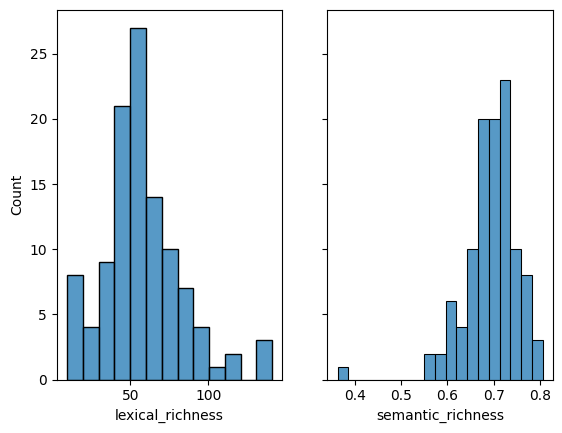

In [48]:
fig, axes = plt.subplots(1,2, sharey=True)
richness = ['lexical_richness', 'semantic_richness']

for ax, r in zip(axes, richness):
    sns.histplot(df_transcripts, x=r, ax=ax)

plt.show()

In [49]:
dfs = [df_merge_analysts, df_merge_ai, df_authors_wide, df_peers_wide]

## Micro Level Analysis

* Micro level analysis is based on semantic similarity between descriptions of films made by the agents. The semantic similarity is calculated using the "paraphrase-multilingual-MiniLM-L12-v2" model from setence-transformers, where embeddings of texts are made and the cosine similarity is calculated. 

### Analysts

In [50]:
columns = ['B.02 - Em uma frase (poucas palavras, suas) sobre o que é o filme analisado? [procure não se ater somente ao título ou sinopse]',
           'B.03 - Qual o tema ou temas que este filme mobilizam?\n[resposta espontânea e aberta de quem analisa]']

df_sv = df_analysts_sv[['film_id'] + columns].copy()
df_vs = df_analysts_vs[['film_id'] + columns].copy()

df_sv['micro'] = df_sv[columns[0]] + '\n' + df_sv[columns[1]]
df_vs['micro'] = df_vs[columns[0]] + '\n' + df_vs[columns[1]]

df_micro_analysts = pd.merge(df_sv[['film_id', 'micro']], df_vs[['film_id', 'micro']], on='film_id', suffixes=('_SV','_VS'))
df_micro_analysts.set_index('film_id', inplace = True)


* Computation of semantic similarity betweem micro descriptions of films by the two analysts

In [51]:
label_a, label_b = ('micro_SV','micro_VS')
df_micro_analysts['similarity'] = df_micro_analysts.apply(lambda row : engineering.semantic_similarity(row, label_a, label_b), axis = 1)

In [52]:
df_micro_analysts['similarity_lemma'] = df_micro_analysts.apply(lambda row : engineering.semantic_similarity(row, label_a, label_b, lemma=True), axis = 1)

### AI

In [53]:
column = 'E.2) Insira aqui a resposta da IA com os dados da análise simulada [por favor, revise antes de enviar]:'

df_chatgpt = df_ai_chatgpt.copy()
df_gemini = df_ai_gemini.copy()

df_chatgpt['micro'] = df_chatgpt[column].str.replace(r"[^A-Za-zÀ-ÖØ-öø-ÿ]+", " ", regex=True).str.strip()
df_gemini['micro'] = df_gemini[column].str.replace(r"[^A-Za-zÀ-ÖØ-öø-ÿ]+", " ", regex=True).str.strip()

df_micro_ai = pd.merge(df_chatgpt[['film_id', 'micro']], df_gemini[['film_id', 'micro']], on = 'film_id', suffixes=('_ChatGPT', '_Gemini'))
df_micro_ai.set_index('film_id', inplace=True)

* Computation of semantic similarity betweem micro descriptions of films by the two AIs

In [54]:
label_a, label_b = ('micro_ChatGPT', 'micro_Gemini')

df_micro_ai['similarity'] = df_micro_ai.apply(lambda row : engineering.semantic_similarity(row, label_a, label_b), axis = 1)

In [55]:
df_micro_ai['similarity_lemma'] = df_micro_ai.apply(lambda row : engineering.semantic_similarity(row, label_a, label_b, lemma=True), axis = 1)

### Authors and peers

In [56]:
df_authors_peers_micro = pd.read_excel(f'{DATA_RAW_DIR}/Dados Autores e Pares/Empilhado_SVVS Partes 1 e 2 Empilhado - regular.xlsx')

* Note: For micro analysis, only data curated by one of the analysts is required

In [57]:
df_authors_peers_micro = df_authors_peers_micro[df_authors_peers_micro['Analista'] == 'VS']

df_authors_micro = df_authors_peers_micro[df_authors_peers_micro['Tipo de Participação autores ou pares'] == 'Participou'].copy()
df_peers_micro = df_authors_peers_micro[df_authors_peers_micro['Tipo de Participação autores ou pares'] == 'Não Participou'].copy()

df_authors_micro['film_id'] = df_authors_micro['ID Filme'].astype(int)
df_peers_micro['film_id'] = df_peers_micro['ID Filme'].astype(int)

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [58]:
df_authors_micro = df_authors_micro[df_authors_micro['film_id'] > 1069000]
df_peers_micro = df_peers_micro[df_peers_micro['film_id'] > 1069000]

In [59]:
columns = ['2013a_Em uma ou duas palavras é um filme sobre...:','2009_Como você resumiria este filme? (em poucas palavras)']

df_authors_micro['micro'] = df_authors_micro[columns[0]] + '\n' + df_authors_micro[columns[1]]
df_peers_micro['micro'] = df_peers_micro[columns[0]] + '\n' + df_peers_micro[columns[1]]

In [60]:
df_authors_micro['rater_index'] = df_authors_micro.groupby('film_id').cumcount().add(1).astype(str).radd('author_')
df_peers_micro['rater_index'] = df_peers_micro.groupby('film_id').cumcount().add(1).astype(str).radd('peer_')

df_authors_micro_wide = df_authors_micro.pivot(index='film_id', columns='rater_index', values='micro')
df_peers_micro_wide = df_peers_micro.pivot(index='film_id', columns='rater_index', values='micro')

* Computation of semantic similarity betweem micro descriptions of films by the all authors. The function engineering.engineering.semantic_similarity_intra compares all pairwise similarities between authors and returns the maximum similarity value.

In [61]:
labels = df_authors_micro_wide.columns

df_micro_authors = pd.DataFrame()
df_micro_authors['similarity'] = df_authors_micro_wide.apply(lambda row : engineering.semantic_similarity_intra(row, labels), axis = 1)

In [62]:
df_micro_authors['similarity_lemma'] = df_authors_micro_wide.apply(lambda row : engineering.semantic_similarity_intra(row, labels, lemma=True), axis = 1)

* Computation of semantic similarity betweem micro descriptions of films by the all peers. The function engineering.engineering.semantic_similarity_intra compares all pairwise similarities between authors and returns the maximum similarity value.

In [63]:
labels = df_peers_micro_wide.columns

df_micro_peers = pd.DataFrame()
df_micro_peers['similarity'] = df_peers_micro_wide.apply(lambda row : engineering.semantic_similarity_intra(row, labels), axis = 1)

In [64]:
df_micro_peers['similarity_lemma'] = df_peers_micro_wide.apply(lambda row : engineering.semantic_similarity_intra(row, labels, lemma=True), axis = 1)

### Comparisons intra dimensions

In [65]:
colors_single = ['#D32F2F', '#FBC02D', '#26C6DA', '#135CAD']

* This section provides a description of how semantic similarities are distributed for each of the dimensions.

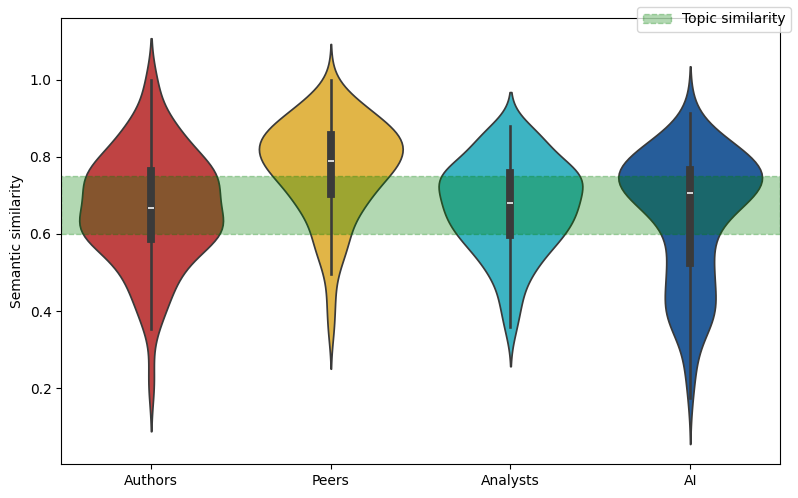

In [66]:
topic_low = 0.60
topic_high = 0.75

dfs_micro = {'Authors' : df_micro_authors, 'Peers' : df_micro_peers, 'Analysts' : df_micro_analysts, 'AI' : df_micro_ai}

df_micro_all = pd.concat([df['similarity'] for df in dfs_micro.values()], axis = 1)
df_micro_all.columns=dfs_micro.keys()

fig, ax = plt.subplots(1,1, figsize=(8,5))
sns.violinplot(df_micro_all, ax = ax, palette=colors_single)
ax.set_ylabel('Semantic similarity')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Topic similarity', alpha = 0.3)

fig.legend()
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_single_max.png', dpi = 300)
plt.show()

df_micro_all.to_excel(f'{RESULTS_TABLES_DIR}/micro_single_max.xlsx')

Result : All dimensions report high semantic similarity, with averages located within topic similarity range. This indicates that for each dimension, the agents agree on the contents of the films in general.

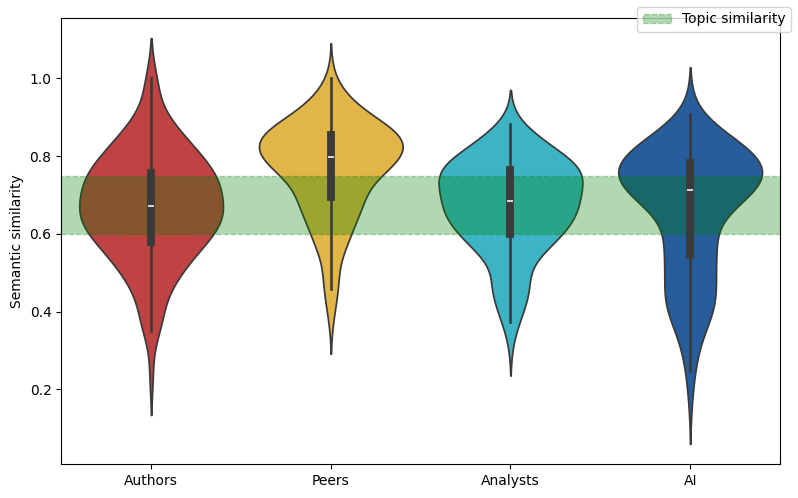

In [67]:
df_micro_all_lemma = pd.concat([df['similarity_lemma'] for df in dfs_micro.values()], axis = 1)
df_micro_all_lemma.columns=dfs_micro.keys()

fig, ax = plt.subplots(1,1, figsize=(8,5))
sns.violinplot(df_micro_all_lemma, ax = ax, palette=colors_single)
ax.set_ylabel('Semantic similarity')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Topic similarity', alpha = 0.3)

fig.legend()
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_single_lemma_max.png', dpi = 300)
plt.show()

df_micro_all_lemma.to_excel(f'{RESULTS_TABLES_DIR}/micro_single_lemma_max.xlsx')

### Comparisons inter dimensions

In [68]:
labels = {'Analysts' : ['micro_VS', 'micro_SV'],
          'AI' : ['micro_ChatGPT', 'micro_Gemini'],
          'Authors' : df_authors_micro_wide.columns,
          'Peers' : df_peers_micro_wide.columns}

dfs_micro_all = {'Analysts' : df_micro_analysts,
       'AI' : df_micro_ai,
       'Authors' : df_authors_micro_wide,
       'Peers' : df_peers_micro_wide}

In [69]:
from itertools import combinations 
import warnings

file_path = f'{RESULTS_DIR}/df_micro_comparisons.csv'

if not os.path.exists(file_path):

    dimension_comparisons = list(combinations(labels.keys(), 2))

    list_dfs = []

    for combination in dimension_comparisons:

        dimension_a, dimension_b = combination

        labels_a = labels[dimension_a]
        labels_b = labels[dimension_b]

        df_merge = pd.merge(dfs_micro_all[dimension_a], dfs_micro_all[dimension_b], on = 'film_id', how ='outer')
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            df_merge[f'{dimension_a} and {dimension_b}'] = df_merge.apply(lambda row: engineering.semantic_similarity_inter(row, labels_a, labels_b), axis = 1)
        
        list_dfs.append(df_merge[f'{dimension_a} and {dimension_b}'])

    df_micro_comparisons = pd.concat(list_dfs, axis = 1, join='outer')
    df_micro_comparisons.to_csv(file_path)

else:
    df_micro_comparisons = pd.read_csv(file_path, index_col=0)

In [70]:
colors_combinations = ['#1290D0', '#C15278', '#7EE0A3', '#8E45E5', '#3B855B', '#F57F17']

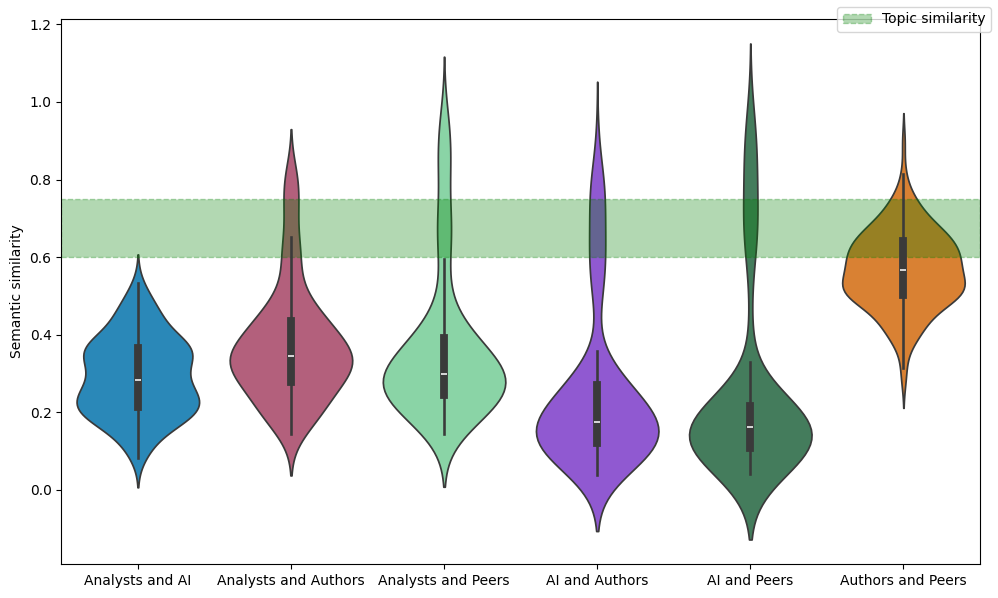

In [71]:
fig, ax = plt.subplots(1,1, figsize=(10,6))

sns.violinplot(data=df_micro_comparisons, ax = ax, palette=colors_combinations)
ax.set_ylabel('Semantic similarity')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Topic similarity', alpha = 0.3)

fig.legend()
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_multi_all.png', dpi = 300)
plt.show()

df_micro_comparisons.to_excel(f'{RESULTS_TABLES_DIR}/micro_multi_all.xlsx')

In [72]:
file_path = f'{RESULTS_DIR}/df_micro_comparisons_lemma.csv'

if not os.path.exists(file_path):

    dimension_comparisons = list(combinations(labels.keys(), 2))

    list_dfs = []

    for combination in dimension_comparisons:

        dimension_a, dimension_b = combination

        labels_a = labels[dimension_a]
        labels_b = labels[dimension_b]

        df_merge = pd.merge(dfs_micro_all[dimension_a], dfs_micro_all[dimension_b], on = 'film_id', how ='outer')
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            df_merge[f'{dimension_a} and {dimension_b}'] = df_merge.apply(lambda row: engineering.semantic_similarity_inter(row, labels_a, labels_b, lemma=True), axis = 1)
        
        list_dfs.append(df_merge[f'{dimension_a} and {dimension_b}'])

    df_micro_comparisons_lemma = pd.concat(list_dfs, axis = 1, join='outer')
    df_micro_comparisons_lemma.to_csv(file_path)

else:
    df_micro_comparisons_lemma = pd.read_csv(file_path, index_col=0)

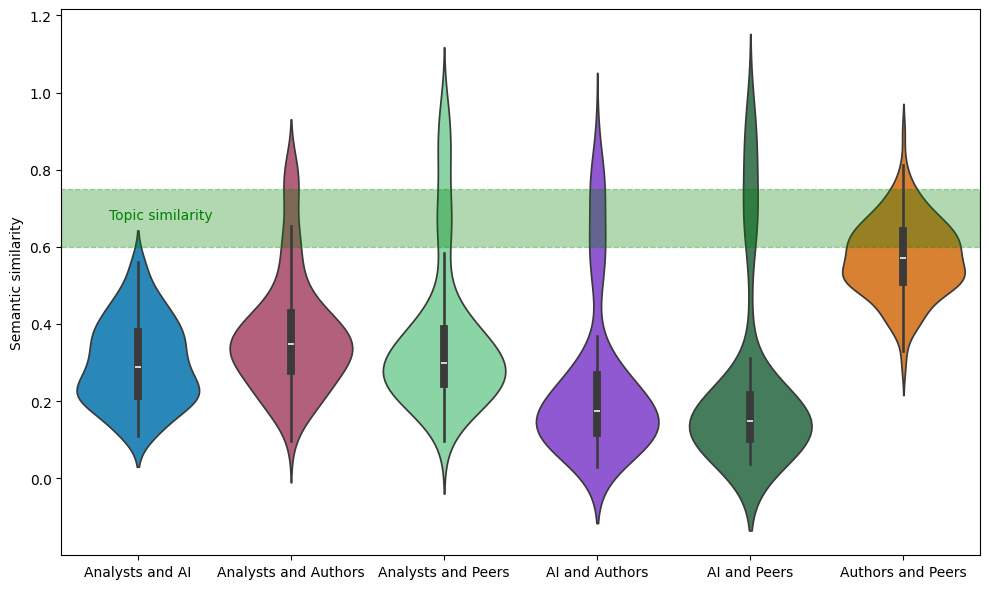

In [73]:
fig, ax = plt.subplots(1,1, figsize=(10,6))

sns.violinplot(data=df_micro_comparisons_lemma, ax = ax, palette=colors_combinations)
ax.set_ylabel('Semantic similarity')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Topic similarity', alpha = 0.3)
ax.text(0.15,
    0.7,
    "Topic similarity",
    ha="center",
    va="top",
    color="green",
    fontsize=10,
)

fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_multi_all_lemma.png', dpi = 300)
plt.show()

df_micro_comparisons_lemma.to_excel(f'{RESULTS_TABLES_DIR}/micro_multi_all_lemma.xlsx')

### Comparison between text richness and micro level 

* In this section, the semantic similarity is plotted against the semantic or lexical richness of texts. A linear fit is attempted, to check if there is a correlation between these two properties across all films. The mean word count is also calculated to see if it has an effect on both these two properties.

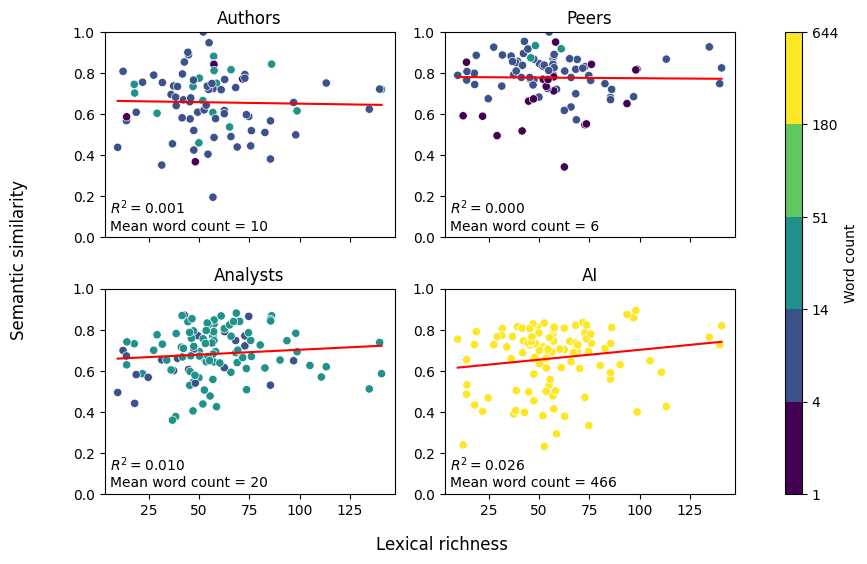

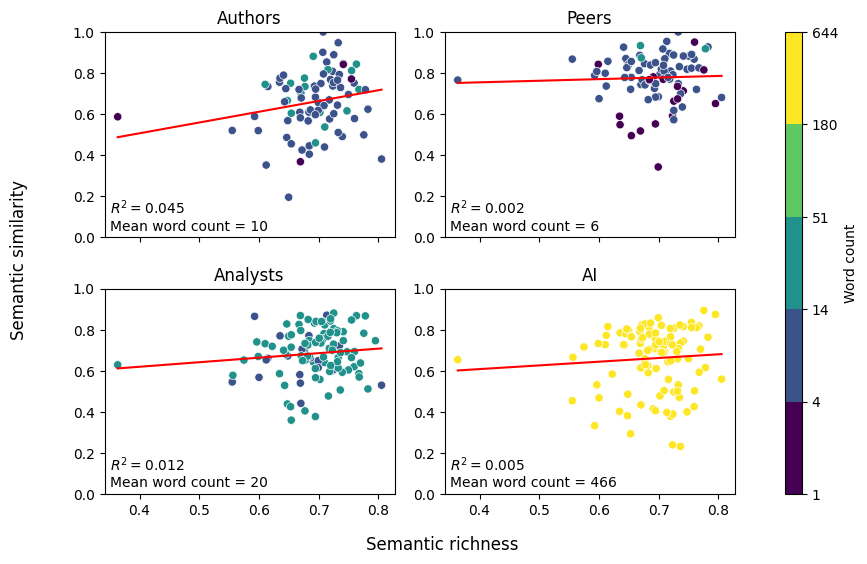

In [74]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable

labels = [1,2,3,4,5]

word_counts = []

for dimension, df in dfs_micro_all.items():
    df_word_count = df.map(lambda x: len(str(x).split()))
    mean = df_word_count.mean(axis=1)
    mean.name = dimension + '_N'
    word_counts.append(mean)

df_word_counts = pd.concat(word_counts, axis = 1)

bins = np.logspace(np.log10(df_word_counts.min().min()),
                   np.log10(df_word_counts.max().max()),
                   6)

def bin_value(x):
    return pd.cut([x], bins=bins, labels=labels, include_lowest=True)[0]

df_bins = df_word_counts.map(bin_value)

cmap_word = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(labels))))
norm_word = BoundaryNorm(bins, cmap_word.N)
palette = {label: cmap_word(i) for i, label in enumerate(labels)}

for richness in ['lexical_richness', 'semantic_richness']:
    df = pd.concat([df_micro_all, df_transcripts[richness]], axis = 1)

    fig = plt.figure(figsize=(9, 6))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.06], height_ratios = [1,1], hspace=0.25, wspace=0.25)

    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[0,1], sharex=ax1)
    ax3 = fig.add_subplot(gs[1,0], sharex=ax1)
    ax4 = fig.add_subplot(gs[1,1], sharex=ax1)

    ax1.tick_params(labelbottom=False)
    ax2.tick_params(labelbottom=False)

    axes = [ax1,ax2,ax3,ax4]
    
    df_out_list = []
    for dimension, ax in zip(dfs_micro.keys(), axes):
        _df_color = df_bins[dimension + '_N']
        _df_color.name = dimension + '_color'
        _df_word_count = df_word_counts[dimension + '_N']
        _df = pd.concat([df[richness], df[dimension], _df_color, _df_word_count], axis = 1)
        
        sns.scatterplot(data=_df, 
                        x=richness, 
                        y=dimension, 
                        hue=f'{dimension}_color', 
                        hue_order=labels,
                        palette=palette,
                        ax=ax,
                        legend=False
                        )
        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.set_ylim(0,1)
        ax.set_title(dimension)

        x_range, y_pred, r2 = engineering.get_fitted(df, richness, dimension)
        mean_word_count = df_word_counts[f'{dimension}_N'].mean()
        ax.plot(x_range, y_pred, color = 'red')
        ax.text(
                0.02, 0.02,
                f"$R^2 = {r2:.3f}$\nMean word count = {mean_word_count:.0f}",
                transform=ax.transAxes,
                fontsize=10,
                va='bottom',
                ha='left'
            )
        if dimension != 'Authors':
            _df = _df.drop(richness, axis = 1)
        df_out_list.append(_df)

    cax = fig.add_subplot(gs[:, 2])

    sm = ScalarMappable(norm=norm_word, cmap=cmap_word)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_ticks(bins)
    cbar.set_ticklabels([f"{b:.0f}" for b in bins])
    cbar.set_label("Word count")
    
    if richness == 'lexical_richness':
        label = 'Lexical richness'
    else:
        label = 'Semantic richness'

    fig.supxlabel(label)
    fig.supylabel('Semantic similarity')
    fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_{richness}.png', dpi = 300)

    df_out = pd.concat(df_out_list, axis = 1)
    df_out.to_excel(f'{RESULTS_TABLES_DIR}/micro_{richness}.xlsx')
    
    plt.show()

### Micro level text richness

In [75]:
def get_text_richness_micro(row):

    row = row[~row.index.str.contains("similarity", case=False, na=False)]
    
    transcript = " ".join(row.dropna())

    if isinstance(transcript, float):
        return np.nan, np.nan

    _clean_transcript = transcript_analysis.clean_transcript(transcript)

    try:
        lexical = transcript_analysis.lexical_richness(_clean_transcript)
    except:
        lexical = np.nan
    try:
        semantic = transcript_analysis.semantic_richness(_clean_transcript)
    except ValueError:
        semantic = np.nan

    return lexical, semantic


file_path = f'{RESULTS_DIR}/df_micro_richness.csv'

if not os.path.exists(file_path):
    results = {}
    for dimension, df in dfs_micro_all.items():
        df_out = pd.DataFrame(index = df.index)
        df_out[['lexical_richness', 'semantic_richness']] = df.apply(get_text_richness_micro, axis = 1, result_type='expand')

        results[dimension] = df_out
    
    df_micro_richness = pd.concat({k : v for k,v in results.items()}, axis = 1)
    df_micro_richness = df_micro_richness.swaplevel(0,1, axis = 1)
    df_micro_richness = df_micro_richness.sort_index(axis = 1)
    df_micro_richness.to_csv(file_path)
else: 
    df_micro_richness = pd.read_csv(file_path, index_col=0, header=[0,1])

df_micro_richness = df_micro_richness.reindex(columns=['Authors', 'Peers', 'Analysts', 'AI'], level = 1)

In [76]:
df_micro_richness.to_excel(f'{RESULTS_TABLES_DIR}/micro_textual_richness.xlsx')

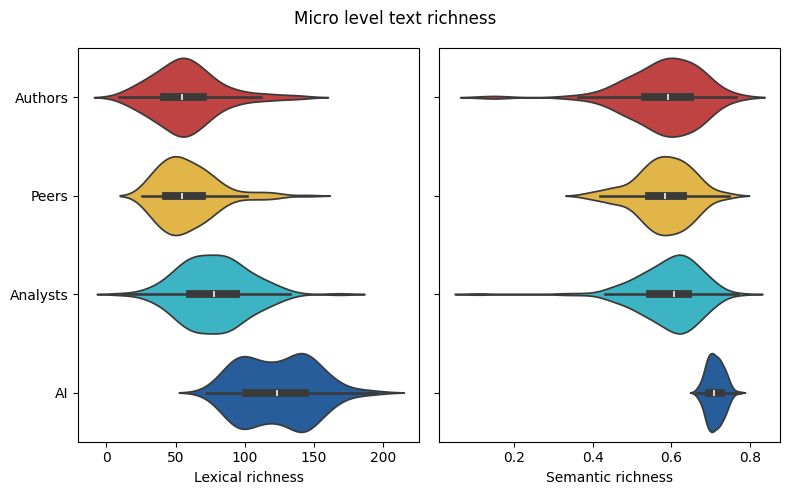

In [77]:
fig, axes = plt.subplots(1,2, sharey=True, figsize=(8,5))
for richness,ax in zip(['lexical_richness', 'semantic_richness'], axes):
    df = df_micro_richness.xs(richness, level=0, axis = 1)
    sns.violinplot(data=df, ax = ax, orient='h', palette=colors_single)
    
    if richness == 'semantic_richness':
        label = 'Semantic richness'
    else:
        label = 'Lexical richness'
    ax.set_xlabel(label)
fig.suptitle('Micro level text richness')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_textual_richness.png', dpi = 300)

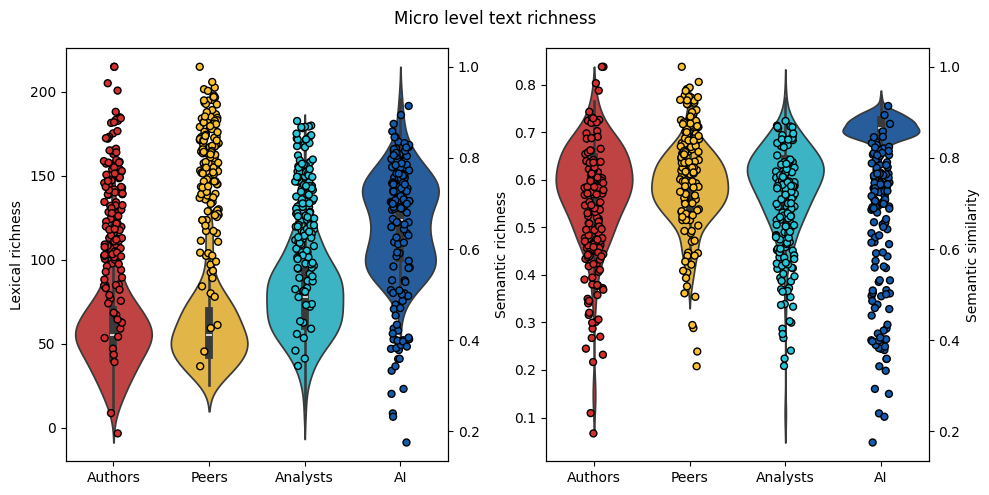

In [78]:
dfs_micro_ordered = {col: dfs_micro[col] for col in df_micro_richness.columns.get_level_values(level=1).unique()}

fig, axes = plt.subplots(1,2, figsize=(10,5))
for richness,ax in zip(['lexical_richness', 'semantic_richness'], axes):
    df = df_micro_richness.xs(richness, level=0, axis = 1)
    sns.violinplot(data=df, ax = ax, palette=colors_single)
    
    if richness == 'semantic_richness':
        label = 'Semantic richness'
    else:
        label = 'Lexical richness'
    ax.set_ylabel(label)

for ax in axes:

    df_all = pd.concat({dimension : df['similarity'] for dimension, df in dfs_micro_ordered.items()}, axis = 1)
    secx = ax.twinx()
    if ax == axes[-1]:
        secx.set_ylabel('Semantic similarity')
    sns.stripplot(data=df_all, ax = secx, edgecolor='black', linewidth=1, palette=colors_single)

fig.suptitle('Micro level text richness')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_textual_richness_similarity_violin.png', dpi = 300)

In [79]:
df_authors_micro_levels = df_authors_peers_micro[df_authors_peers_micro['Tipo de Participação autores ou pares'] == 'Participou'].copy()
df_authors_micro_levels['film_id'] = df_authors_micro_levels['ID Filme']



columns = ['2013a_Em uma ou duas palavras é um filme sobre...:','2009_Como você resumiria este filme? (em poucas palavras)']
column_author_level = 'Score de Participação autores ou pares de 0 a 5'

df_authors_micro_levels['micro'] = df_authors_micro[columns[0]] + '\n' + df_authors_micro[columns[1]]
df_authors_micro_levels['author_index'] = df_authors_micro_levels.groupby(['film_id', column_author_level]).cumcount()  + 1

df_authors_micro_levels_wide = df_authors_micro_levels.pivot(index='film_id', columns=[column_author_level,'author_index'], values='micro')
df_authors_micro_levels_wide.sort_index(axis=1, inplace= True)


In [80]:
def get_text_richness_micro_agent(transcript):
    
    if isinstance(transcript, float):
        return np.nan, np.nan

    _clean_transcript = transcript_analysis.clean_transcript(transcript)

    try:
        lexical = transcript_analysis.lexical_richness(_clean_transcript)
    except:
        lexical = np.nan
    try:
        semantic = transcript_analysis.semantic_richness(_clean_transcript)
    except ValueError:
        semantic = np.nan

    return lexical, semantic

_dfs_micro = {'Authors' : df_authors_micro_levels_wide, 
              'Peers' : df_peers_micro_wide, 
              'Analysts' : df_micro_analysts[['micro_SV','micro_VS']], 
              'AI' : df_micro_ai[['micro_ChatGPT','micro_Gemini']]}

dfs_micro_text_richness = {}
for dimension, df in _dfs_micro.items():

    file_path = f'{RESULTS_DIR}/df_micro_text_richness_{dimension}.csv'

    if not os.path.exists(file_path):

        df_out = pd.concat({col: df[col].map(get_text_richness_micro_agent).apply(pd.Series) for col in df.columns}, axis=1)
        df_out.rename(columns={0: "lexical_richness", 1: "semantic_richness"}, level=-1, inplace=True)
        df_out.columns = df_out.columns.set_names(df.columns.names + ['text_richness'])
        
        df_out.to_csv(file_path)
    else:
        if dimension == 'Authors':
            headers = [0,1,2]
        else:
            headers = [0,1]

        df_out = pd.read_csv(file_path, index_col=0, header = headers)    
    
    dfs_micro_text_richness[dimension] = df_out



In [81]:
colors_agents = ['#EF9A9A', '#E53935', '#B71C1C', '#FDD835', '#1FA7C5', '#0097A7', '#4C9FEA', '#1E88E5']

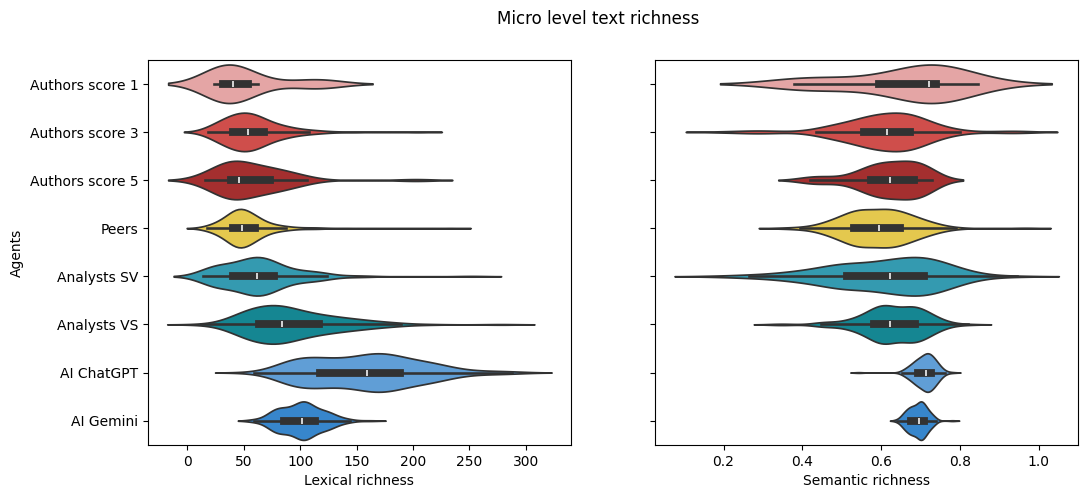

In [82]:
fig, axes = plt.subplots(1,2, sharey=True, figsize=(12,5))

for richness, ax in zip(['lexical_richness', 'semantic_richness'], axes):
    
    df_richness_list = []
    for dimension, df in dfs_micro_text_richness.items():
        df = df.xs(richness, level = -1, axis = 1)
        if dimension != 'Peers':
                
            df = df.T.groupby(level=0).mean().T

            if dimension == 'Authors':
                df.rename(columns = {col : f'{dimension} score {col}' for col in df.columns}, inplace=True)
            else:
                df.rename(columns = {col : f'{dimension} {col.replace('micro_', '')}' for col in df.columns}, inplace = True)
            
        else:
            df = df.T.groupby(level=0).mean().mean()
            df.name = dimension
        df_richness_list.append(df)

    df_richness = pd.concat(df_richness_list, axis = 1)

    sns.violinplot(data=df_richness, orient='h', ax = ax, palette=colors_agents)
    ax.set_ylabel('Agents')
    
    if richness == 'lexical_richness':
        label = 'Lexical richness'
    else:
        label = 'Semantic richness'
    ax.set_xlabel(label)

    df_richness.to_excel(f'{RESULTS_TABLES_DIR}/micro_{richness}_agents.xlsx')

fig.suptitle('Micro level text richness')
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_textual_richness_agents.png', dpi = 300)
plt.show()

## Meso Level Analysis

In [83]:
dfs_meso = {}
dfs_meso_agreements = {}
column_themes = ['Tema 0', 'Tema 2', 'Tema 3']

### Analysts

1. Theme extraction

In [84]:
for col in column_themes:

    df_analysts_sv[col] = df_analysts_sv[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()
    df_analysts_vs[col] = df_analysts_vs[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

* Note: manual correction of categories

In [85]:
df_analysts_sv.set_index('film_id', inplace = True)
df_analysts_vs.set_index('film_id', inplace = True)

df_analysts_sv.loc[1080403, 'Tema 3'] = 'recreação, lazer e entretenimento'
df_analysts_sv.loc[1110215, 'Tema 3'] = 'solidão'

In [86]:
df_merge_analysts = pd.concat({'SV' : df_analysts_sv[column_themes], 'VS' : df_analysts_vs[column_themes]}, axis = 1)

#### IRR

In [87]:
alphas = []

df_num = engineering.cat_to_numeric(df_merge_analysts)

for col in column_themes:
    data = df_num.xs(col, level=1, axis = 1)

    alphas.append(krippendorff.alpha(reliability_data=data.T, level_of_measurement='nominal'))

dfs_meso['Analysts'] = pd.DataFrame(alphas, index=column_themes, columns=[r'Krippendorff $\alpha$'])

In [88]:
agreements = []

for col in column_themes:

    df = df_merge_analysts.xs(col, level = 1, axis = 1)

    agreement = df['VS'] == df['SV']

    agreements.append((agreement.sum() / len(df))*100)

dfs_meso_agreements['Analysts'] = pd.DataFrame(agreements, index = column_themes, columns=['Agreement ratio (%)'])

### AI

In [89]:
df_ai = pd.read_excel(f'{DATA_RAW_DIR}/Dados IA/AN-IAv3 - SVVS_ChatGPT-Gemini.xlsx')

In [90]:
df_ai['film_id'] = df_ai['IDFilme_NOVOID3']
#df_ai.set_index('film_id', inplace = True)

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [91]:
df_ai = df_ai[df_ai['film_id'] > 1069000]

1. Theme extraction

In [92]:
df_ai.rename(columns={'Tema 1' : 'Tema 0'}, inplace=True)

for col in column_themes:
    df_ai[col] = df_ai[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

In [93]:
df_ai_gemini = df_ai[df_ai['NA (quem processou a IA)'] == 'VS'].copy()
df_ai_chatgpt = df_ai[df_ai['NA (quem processou a IA)'] == 'SV'].copy()

df_ai_gemini['film_id'] = df_ai_gemini['IDFilme_NOVOID3']
df_ai_chatgpt['film_id'] = df_ai_chatgpt['IDFilme_NOVOID3']

Note: Some films were passed through the AI more than once. Those are indentified below and then duplicates are removed, keeping only the last passage.

In [94]:
df_ai_chatgpt[df_ai_chatgpt['film_id'].duplicated(keep=False)].sort_values(by='film_id')[['film_id', 'Oficina','ID']]

,film_id,Oficina,ID
66,1080411,10804,4067
169,1080411,10804,4170
81,1090102,10901,4082
80,1090102,10901,4081
106,1110209,11102,4107
118,1110209,11102,4119


In [95]:
df_ai_gemini[df_ai_gemini['film_id'].duplicated(keep=False)].sort_values(by='film_id')[['film_id', 'Oficina','ID']]

,film_id,Oficina,ID
176,1070107,10701,5007
177,1070107,10701,5008
192,1080107,10801,5023
193,1080107,10801,5024
221,1080410,10804,5052
222,1080410,10804,5053


In [96]:
df_ai_chatgpt = df_ai_chatgpt.sort_values('ID').drop_duplicates(subset='film_id', keep = 'last').set_index('film_id')      
df_ai_gemini = df_ai_gemini.sort_values('ID').drop_duplicates(subset='film_id', keep = 'last').set_index('film_id')

#df_ai_chatgpt.index = df_ai_chatgpt.index.astype(str)
#df_ai_gemini.index = df_ai_gemini.index.astype(str)

df_merge_ai = pd.concat({'ChatGPT' : df_ai_chatgpt[column_themes], 'Gemini' : df_ai_gemini[column_themes]}, axis = 1)



#### IRR

In [97]:
alphas = []

df_num = engineering.cat_to_numeric(df_merge_ai)

for col in column_themes:
    data = df_num.xs(col, level=1, axis = 1)

    alphas.append(krippendorff.alpha(reliability_data=data.T, level_of_measurement='nominal'))

dfs_meso['AI'] = pd.DataFrame(alphas, index=column_themes, columns=[r'Krippendorff $\alpha$'])

In [98]:
agreements = []

for col in column_themes:

    df = df_merge_ai.xs(col, level = 1, axis = 1)

    agreement = df['ChatGPT'] == df['Gemini']

    agreements.append((agreement.sum() / len(df))*100)

dfs_meso_agreements['AI'] = pd.DataFrame(agreements, index = column_themes, columns=['Agreement ratio (%)'])

### Authors and Peers

In [99]:
df_authors_peers = pd.read_excel(f'{DATA_RAW_DIR}/Dados Autores e Pares/Empilhado_SVVS Partes 1 e 2 Empilhado - regular.xlsx')

In [100]:
df_authors_peers['film_id'] = df_authors_peers['ID Filme']
df_authors_peers = df_authors_peers[df_authors_peers['film_id'] > 1069000]

In [101]:
df_authors_peers.set_index(['Analista','film_id'], inplace = True)

1. Theme extraction

In [102]:
for col in column_themes:
    
    df_authors_peers[col] = df_authors_peers[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

In [103]:
column_status = 'Tipo de Participação autores ou pares'

df_authors = df_authors_peers[df_authors_peers[column_status] == 'Participou'].copy()
df_peers = df_authors_peers[df_authors_peers[column_status] == 'Não Participou'].copy()

df_authors_vs = df_authors.loc['VS']
df_authors_sv = df_authors.loc['SV']

df_peers_vs = df_peers.loc['VS']
df_peers_sv = df_peers.loc['SV']

#### IRR

In [104]:
df_supervisors = {'SV' : {'authors' : df_authors_sv, 'peers' : df_peers_sv},
       'VS' : {'authors' : df_authors_vs, 'peers' : df_peers_vs}}

results = []
for analyst, analyst_df in df_supervisors.items():
    for label, df in analyst_df.items():
        df = df.copy()
        df[label] = df.groupby('film_id').cumcount() + 1
        pt = df.reset_index(drop=False).set_index(['film_id', label])[column_themes].unstack(label)

        df_num = engineering.cat_to_numeric(pt[column_themes])

        themes = pt.columns.get_level_values(0).unique()

        for theme in themes:
            data = df_num.xs(theme, level=0, axis = 1)

            results.append([analyst, label, theme, krippendorff.alpha(data.T)])

df_results = pd.DataFrame(results, columns=['Analyst', 'Dimension', 'Theme', r'Krippendorff $\alpha$'])

In [105]:
dfs_meso['Authors'] = df_results[df_results['Dimension'] == 'authors'].pivot_table(values = r'Krippendorff $\alpha$', columns='Analyst', index='Theme')
dfs_meso['Peers'] = df_results[df_results['Dimension'] == 'peers'].pivot_table(values = r'Krippendorff $\alpha$', columns='Analyst', index='Theme')

In [106]:
results = []
for analyst, analyst_df in df_supervisors.items():
    for label, df in analyst_df.items():
        df = df.copy()
        df[label] = df.groupby('film_id').cumcount() + 1
        pt = df.reset_index(drop=False).set_index(['film_id', label])[column_themes].unstack(label)

        for theme in column_themes:
            for film_id, row in pt[theme].iterrows():
                results.append([film_id, analyst, label, theme, row.dropna().duplicated().any()])

df_results_agreement = pd.DataFrame(results, columns = ['film_id', 'Analyst', 'Dimension', 'Theme', 'Agreement'])
        

In [107]:
from itertools import product

results = []

combinations = list(product(column_themes, ['authors', 'peers'], ['VS', 'SV']))

for combination in combinations:
    theme, dimension, analyst = combination

    df = df_results_agreement[(df_results_agreement['Theme'] == theme) & 
                    (df_results_agreement['Dimension'] == dimension) &
                    (df_results_agreement['Analyst'] == analyst)]

    results.append([theme, dimension, analyst, (df['Agreement'].sum() / len(df))*100])

df_results_agreement = pd.DataFrame(results, columns=['Theme', 'Dimension', 'Analyst', 'Agreement ratio (%)'])

dfs_meso_agreements['Authors'] = df_results_agreement[df_results_agreement['Dimension'] == 'authors'].pivot_table(values = 'Agreement ratio (%)', columns='Analyst', index='Theme')
dfs_meso_agreements['Peers'] = df_results_agreement[df_results_agreement['Dimension'] == 'peers'].pivot_table(values = 'Agreement ratio (%)', columns='Analyst', index='Theme')


### IRR

#### Krippendorff's alpha

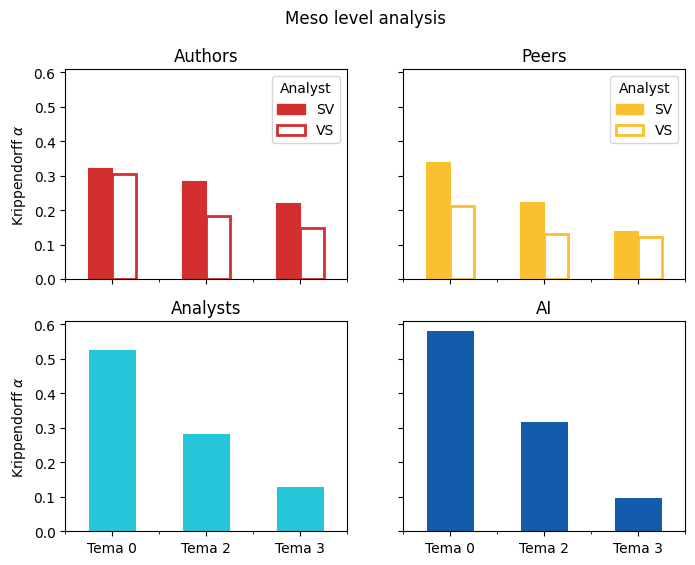

In [108]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8,6))

dfs_meso = {k : dfs_meso[k] for k in ['Authors', 'Peers', 'Analysts', 'AI']}

for idx, ((label, df), ax) in enumerate(zip(dfs_meso.items(), axes.flat)):
    if label in ['Authors', 'Peers']:
        legend = True
    else:
        legend = False
    
    df.plot(kind='bar', ax = ax, legend=legend, color=colors_single[idx])

    if label in ['Authors', 'Peers']:

        n_rows, n_cols = df.shape
        bars = ax.patches

        for col_idx in range(n_cols):
            for row_idx in range(n_rows):
                i = col_idx * n_rows + row_idx
                bar = bars[i]
        
                if col_idx == 0:
                    bar.set_facecolor(colors_single[idx])
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(1.5)
                else:
                    bar.set_facecolor("none")
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(2.0)
        legend_items = [Patch(facecolor=colors_single[idx], edgecolor=colors_single[idx], label=df.columns[0]),
                        Patch(facecolor="none", edgecolor=colors_single[idx], linewidth=2, label=df.columns[1])]
        
        ax.legend(handles=legend_items, title="Analyst")


    ax.set_ylabel(r'Krippendorff $\alpha$')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(label)

fig.suptitle('Meso level analysis')
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso.png')
plt.show()

In [109]:
df = pd.concat({k : v for k,v in dfs_meso.items()}, axis = 1)
df.to_excel(f'{RESULTS_TABLES_DIR}/meso.xlsx')

#### Agreement ratio

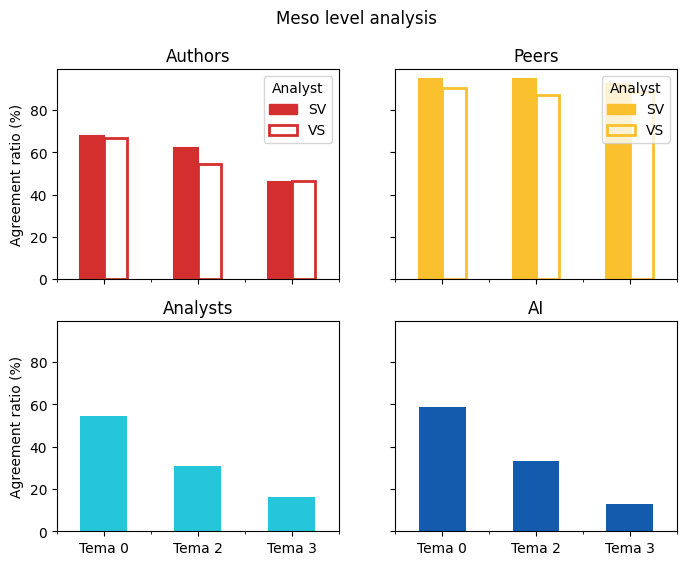

In [110]:
fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8,6))

dfs_meso_agreements = {k : dfs_meso_agreements[k] for k in ['Authors', 'Peers', 'Analysts', 'AI']}

for idx, ((label, df), ax) in enumerate(zip(dfs_meso_agreements.items(), axes.flat)):
    if label in ['Authors', 'Peers']:
        legend = True
    else:
        legend = False
    df.plot(kind='bar', ax = ax, legend=legend, color=colors_single[idx])

    if label in ['Authors', 'Peers']:

        n_rows, n_cols = df.shape
        bars = ax.patches

        for col_idx in range(n_cols):
            for row_idx in range(n_rows):
                i = col_idx * n_rows + row_idx
                bar = bars[i]
        
                if col_idx == 0:
                    bar.set_facecolor(colors_single[idx])
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(1.5)
                else:
                    bar.set_facecolor("none")
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(2.0)
        legend_items = [Patch(facecolor=colors_single[idx], edgecolor=colors_single[idx], label=df.columns[0]),
                        Patch(facecolor="none", edgecolor=colors_single[idx], linewidth=2, label=df.columns[1])]
        
        ax.legend(handles=legend_items, title="Analyst")
    
    ax.set_ylabel('Agreement ratio (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(label)

fig.suptitle('Meso level analysis')
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_concordancia.png')
plt.show()

In [111]:
df = pd.concat({k : v for k,v in dfs_meso_agreements.items()}, axis = 1)
df.to_excel(f'{RESULTS_TABLES_DIR}/meso_concordancia.xlsx')

In [112]:
import collections

dfs_dimensions = {'authors' : {'SV' : df_authors_sv, 'VS' : df_authors_vs}, 
                  'peers' : {'SV' : df_peers_sv, 'VS' : df_peers_vs}
                  }

processed_dfs = collections.defaultdict(dict)

for dimension, dfs in dfs_dimensions.items():
    for analyst, df in dfs.items():
        df = df.copy()
        df['rater'] = df.groupby('film_id').cumcount().add(1)

        df_long = df.reset_index(drop=False).set_index(['film_id', 'rater'])
        df_long = df_long[column_themes]

        df_wide = df_long.unstack('rater')
        df_wide.columns = df_wide.columns.swaplevel(0,1)
        df_wide = df_wide.sort_index(axis = 1, level=[0,1])

        processed_dfs[dimension][analyst] = df_wide

In [113]:
df_merge_authors = pd.concat({'SV' : processed_dfs['authors']['SV'], 'VS' : processed_dfs['authors']['VS']}, axis = 1)
df_merge_peers = pd.concat({'SV' : processed_dfs['peers']['SV'], 'VS' : processed_dfs['peers']['VS']}, axis = 1)

In [114]:
df_merge_analysts.columns = df_merge_analysts.columns.set_names(['rater', 'level'])
df_merge_ai.columns = df_merge_ai.columns.set_names(['rater', 'level'])
df_merge_authors.columns = df_merge_authors.columns.set_names(['supervisor', 'rater', 'level'])
df_merge_peers.columns = df_merge_peers.columns.set_names(['supervisor', 'rater', 'level'])

In [115]:
dfs = {'Authors' : df_merge_authors,  
       'Peers' : df_merge_peers, 
       'Analysts' : df_merge_analysts,
       'AI' : df_merge_ai
       }

#### Human vs AI correspondence

In [116]:
flat = {}

for dimension, df in dfs.items():
    df_flat = df.copy()
    df_flat.columns = ["_".join(map(str, col)) for col in df.columns]

    flat[dimension] = df_flat

dfs_flat = pd.concat({k : v for k,v in flat.items()}, axis=1)

def get_human_ai_correspondence(row):

    human = row[row.index.get_level_values(0).isin(['Authors','Peers', 'Analysts'])].dropna()
    ai = row[row.index.get_level_values(0).isin(['AI'])].dropna()

    human_categories = set(human.unique())
    ai_categories = set(ai.unique())
    
    if len(human_categories.intersection(ai_categories)):
        return True
    else:
        return False

dfs_flat['correspondence'] = dfs_flat.apply(get_human_ai_correspondence, axis = 1)

dfs_flat['correspondence'].describe()


count      178
unique       2
top       True
freq       150
Name: correspondence, dtype: object

#### MASI

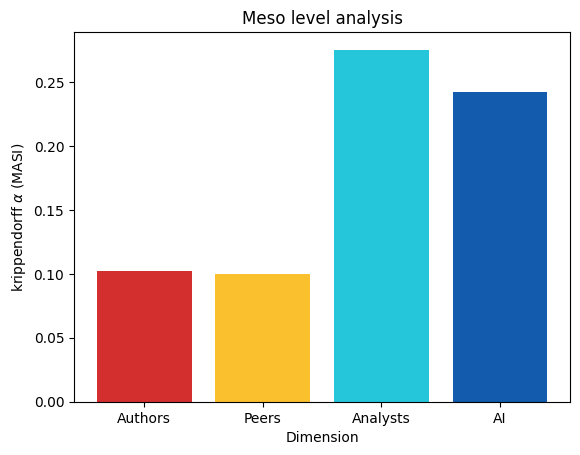

In [117]:
alphas = []
for dimension, df in dfs.items():
    alpha = engineering.krippendorff_alpha_masi(df)
    alphas.append(alpha)    

plt.bar(dfs.keys(), alphas, color = colors_single)
plt.xlabel('Dimension')
plt.ylabel(r'krippendorff $\alpha$ (MASI)')
plt.title('Meso level analysis')
plt.savefig(f'{RESULTS_FIGURES_DIR}/meso_MASI.png', dpi = 300)
plt.show()

df = pd.DataFrame([alphas], columns=dfs.keys())
df.to_excel(f'{RESULTS_TABLES_DIR}/meso_MASI.xlsx')

### Category agreement

In [118]:
categories = set()
for df in dfs.values():
    for col in df.columns:
        categories.update(df[col].dropna().unique())
categories = sorted(list(categories), reverse=True)

In [119]:
results = []
for dimension, df in dfs.items():

    df_labels = df.xs('Tema 0', level=-1, axis = 1)
    #df_labels = df.loc[:, df.columns.get_level_values(-1).isin(column_themes)] # it gives very low alphas for all dimensions
    if dimension in ['Authors', 'Peers']:
        df_labels = (df_labels.stack(level=0, future_stack=True).reset_index()).set_index('film_id').drop('supervisor', axis = 1)
    alphas = []
    for cat in categories:
        df_cat = (df_labels == cat).astype(float)
        if df_cat.sum().sum() == 0:
            alpha = np.nan
        else:
            alpha = krippendorff.alpha(reliability_data=df_cat.T, level_of_measurement='nominal')
        alphas.append(alpha)
    
    results.append(alphas)

df_alphas_categories = pd.DataFrame(np.asarray(results).T, columns=dfs.keys(), index = categories)    

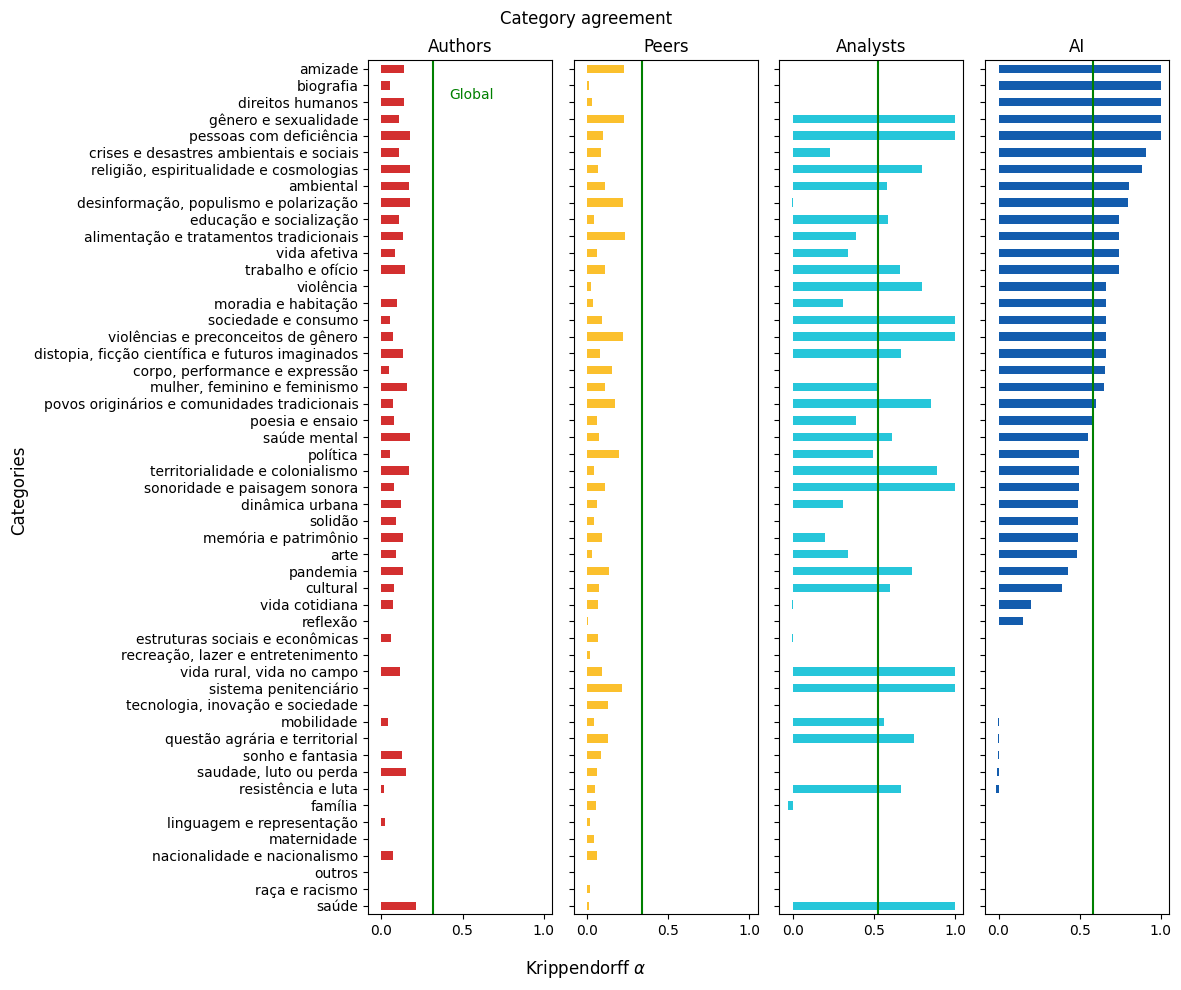

In [120]:
fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

df_sorted = df_alphas_categories['AI'].sort_values(na_position='first')
df_alphas_categories_sorted = df_alphas_categories.loc[df_sorted.index]

for idx, (col, ax) in enumerate(zip(['Authors', 'Peers', 'Analysts', 'AI'], axes.flat)):
    
    df_alphas_categories_sorted[col].plot(kind='barh', ax = ax, color = colors_single[idx])
    ax.set_title(col)
    ax.axvline(dfs_meso[col].loc['Tema 0'].values[0], color = 'green')
    ax.set_xticks([0,0.5,1])

    if ax == axes[0]:
        ax.text(x=dfs_meso[col].loc['Tema 0'].values[0] + 0.1, y = 48,
        s='Global', 
        color='green', 
        fontsize=10,
        va='bottom',
        ha='left',
        backgroundcolor='white'
        )

fig.suptitle('Category agreement')
fig.supxlabel(r'Krippendorff $\alpha$')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_per_cat.png', dpi = 300)
plt.show()

df_alphas_categories_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_per_cat.xlsx')

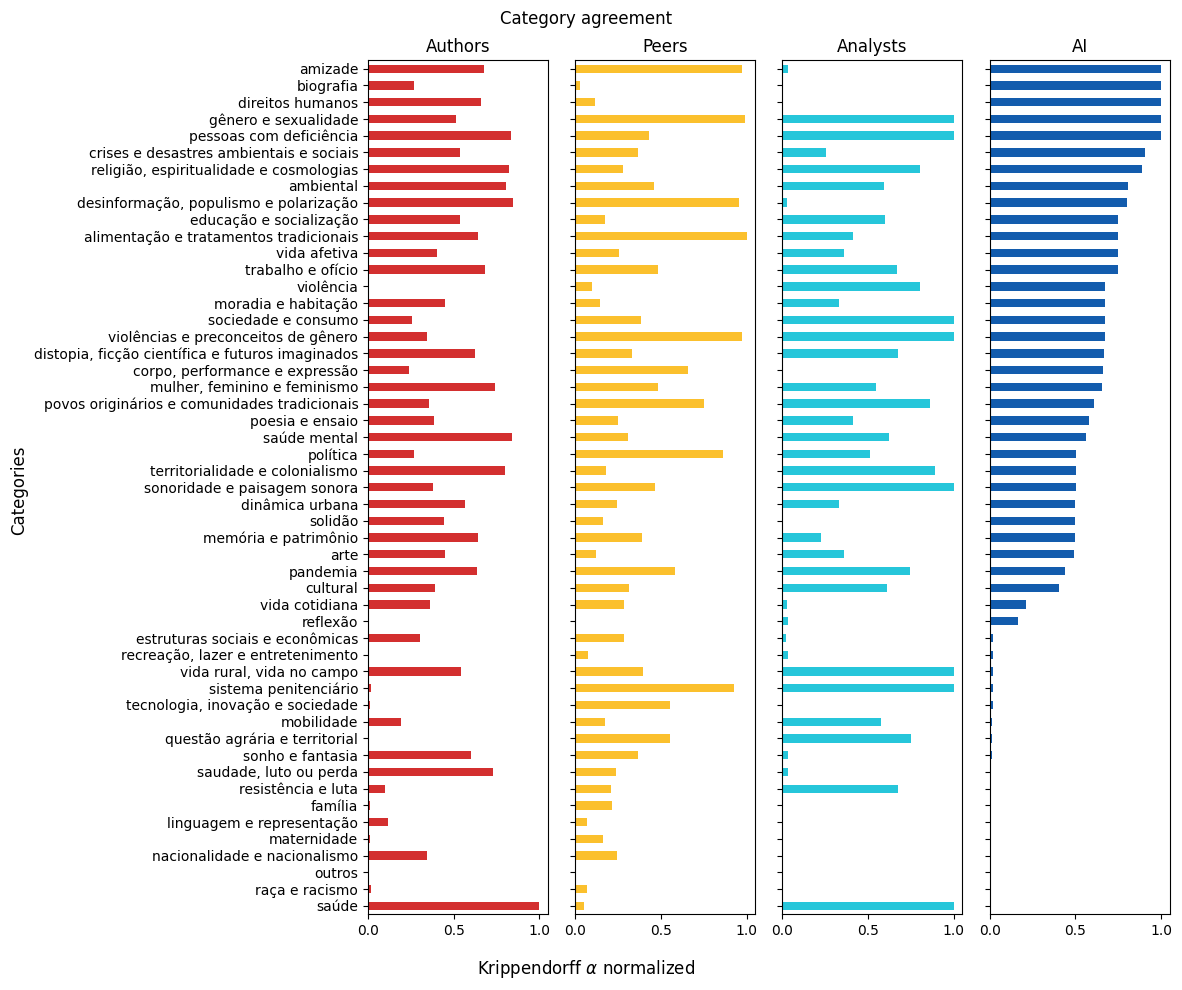

In [121]:
fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

df_alphas_categories_normalized = (df_alphas_categories - df_alphas_categories.min()) / (df_alphas_categories.max() - df_alphas_categories.min())
df_alphas_categories_normalized = df_alphas_categories_normalized.sort_values(by='AI', na_position='first')

for idx, (col, ax) in enumerate(zip(df_alphas_categories_normalized.columns, axes.flat)):
    data = df_alphas_categories_normalized[col]
    data.plot(kind='barh', ax = ax, color=colors_single[idx])
    ax.set_title(col)
    #ax.axvline(dfs_meso[col].loc['Tema 0'].values[0], color = 'green')
    ax.set_xticks([0,0.5,1])

fig.suptitle('Category agreement')
fig.supxlabel(r'Krippendorff $\alpha$ normalized')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_per_cat_minmax.png', dpi = 300)
plt.show()

df_alphas_categories_normalized.to_excel(f'{RESULTS_TABLES_DIR}/meso_per_cat_minmax.xlsx')

In [122]:
results = []
for dimension, df in dfs.items():

    agreements = []
    for cat in categories:
        df_cat = (df == cat).astype(float)
        
        agreement_ratio = ((df_cat.eq(1).sum(axis=1) > 1).sum() / len(df_cat))*100
        agreements.append(agreement_ratio)
    
    results.append(agreements)

df_agreements_categories = pd.DataFrame(np.asarray(results).T, columns=dfs.keys(), index = categories)    

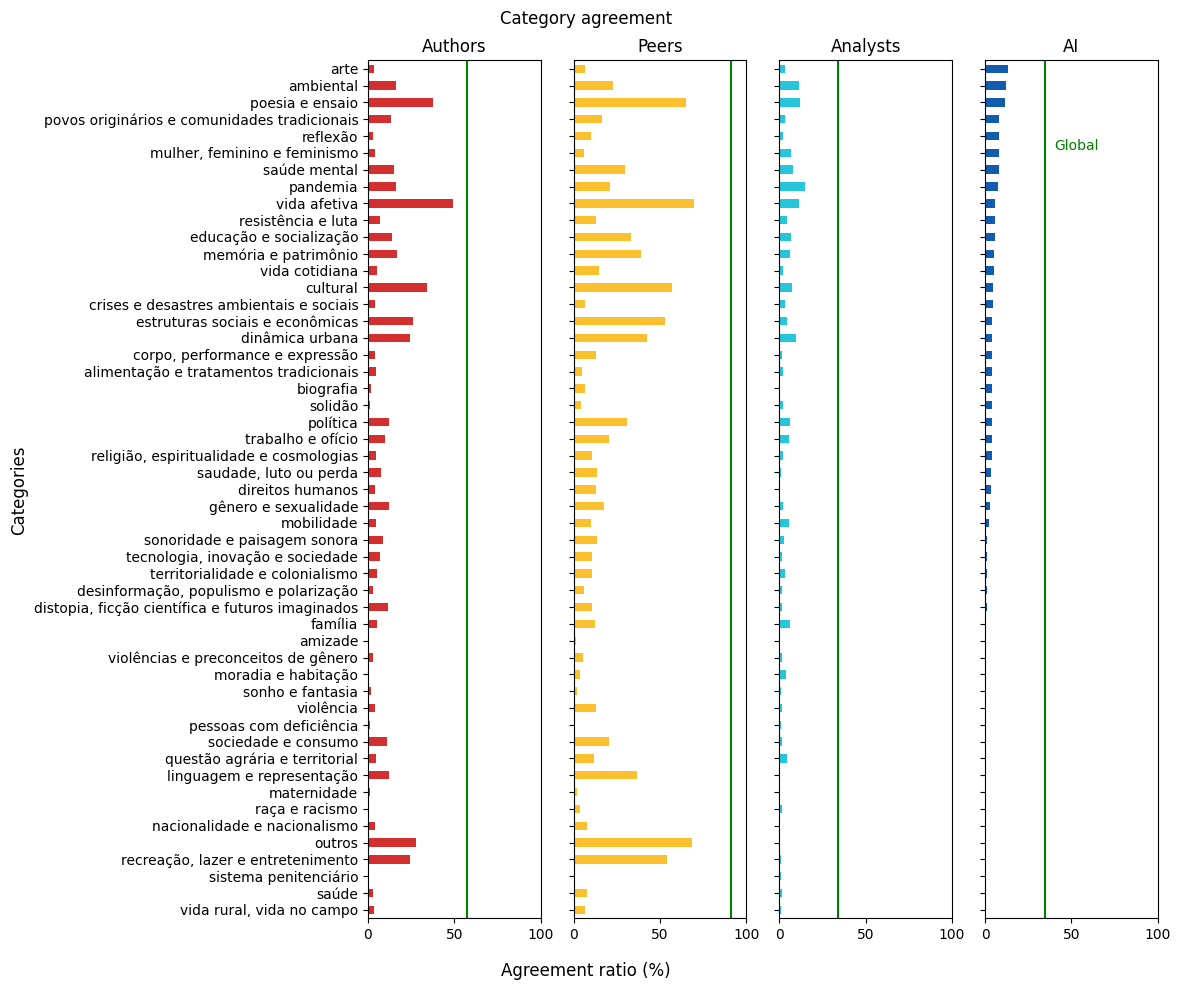

In [123]:
df_agreements_categories = df_agreements_categories.sort_values(by='AI', na_position='first')

fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

for idx, (col, ax) in enumerate(zip(df_agreements_categories.columns, axes.flat)):
    df_agreements_categories[col].plot(kind='barh', ax = ax, color = colors_single[idx])
    ax.set_title(col)
    if col in ['Authors', 'Peers']:
        vline = dfs_meso_agreements[col].mean().mean()
    else:
        vline = dfs_meso_agreements[col].mean().values[0] 
    ax.axvline(vline, color = 'green')
    ax.set_xticks([0,50,100])

    if ax == axes[-1]:
        ax.text(x=vline + 5, y = 45,
        s='Global', 
        color='green', 
        fontsize=10,
        va='bottom',
        ha='left',
        backgroundcolor='white'
        )

fig.suptitle('Category agreement')
fig.supxlabel('Agreement ratio (%)')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_agreements_per_cat.png', dpi = 300)
plt.show()

df_agreements_categories.to_excel(f'{RESULTS_TABLES_DIR}/meso_agreements_per_cat.xlsx')

### Category usage

#### By dimension

In [124]:
long_frames = []

for dimension, df in dfs.items():
    tmp = df.copy()
    tmp = tmp.reset_index()
    tmp = tmp.rename(columns={tmp.columns[0]: "film_id"})
    
    flat_cols = []
    for col in tmp.columns:
        if any(str(c) == "film_id" for c in col):
            flat_cols.append("film_id")
        else:
            parts = [str(c) for c in col if c not in (None, "", "nan")]
            flat_cols.append("_".join(parts))
    tmp.columns = flat_cols

    label_cols = [c for c in tmp.columns if c != 'film_id']

    tmp_long = tmp.melt(
        id_vars="film_id",
        value_vars=label_cols,
        var_name="rater_level",
        value_name="label")

    tmp_long["group"] = dimension
    tmp_long = tmp_long.dropna(subset=["label"])

    long_frames.append(tmp_long)

df_long = pd.concat(long_frames, ignore_index=True)

category_counts = (
    df_long
    .groupby(["group", "label"])
    .size()
    .unstack(fill_value=0)
)

category_counts = category_counts.loc[['Authors', 'Peers', 'Analysts', 'AI']]

In [125]:
category_counts.T.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_counts.xlsx')

* Category usage bias is obtained with chi-square calculation.

In [126]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(category_counts)

expected = pd.DataFrame(
    expected,
    index=category_counts.index,
    columns=category_counts.columns,
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

residuals = (category_counts - expected) / np.sqrt(expected)

Chi-square statistic: 1895.7551179499164
Degrees of freedom: 150
p-value: 1.3720871631436334e-299


* Qualitative

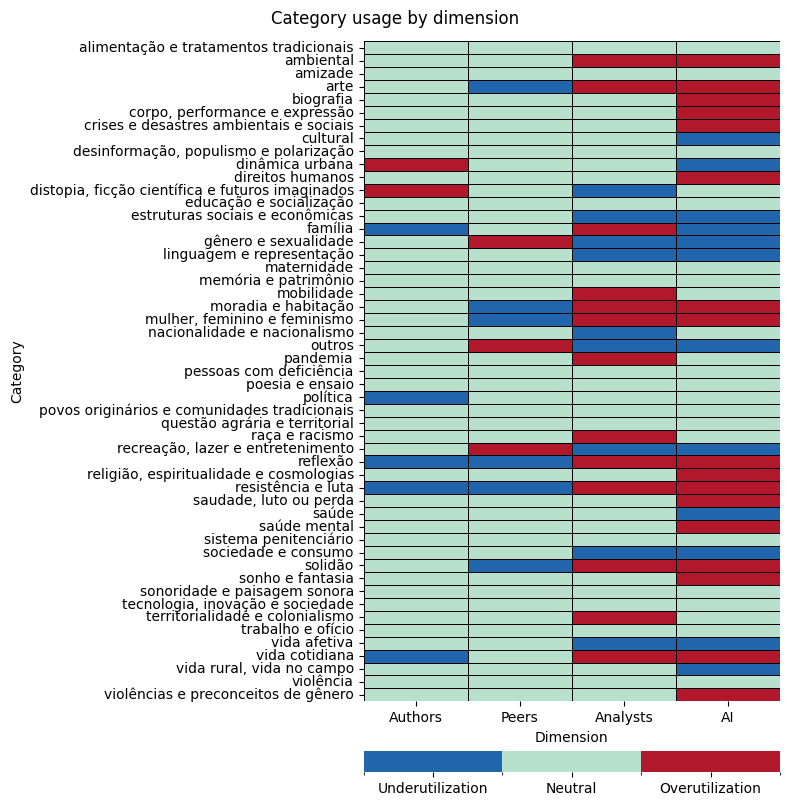

In [127]:
from matplotlib.colors import ListedColormap, BoundaryNorm


vmin = np.nanmin(residuals.values)
vmax = np.nanmax(residuals.values)

underuse_thr = -2
overuse_thr  =  2

# Ensure boundaries cover both data range and thresholds
low_bound  = min(vmin, underuse_thr)
high_bound = max(vmax, overuse_thr)

boundaries = [low_bound, underuse_thr, overuse_thr, high_bound]

colors = [
    "#2166ac",
    "#b7e1cd",   
    "#b2182b" 
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, cmap.N)

fig, ax = plt.subplots(1,1, figsize=(8,9))

sns.heatmap(residuals.T, 
            cmap=cmap,
            norm=norm, 
            ax = ax,
            linewidths=0.5,
            linecolor='black',
            cbar_kws={"orientation": "horizontal", "pad": 0.06}
            )
ax.set_yticks(np.arange(0.5, category_counts.shape[1] + 0.5))
ax.set_yticklabels(category_counts.columns)
ax.set_xlabel('Dimension')
ax.set_ylabel('Category')

cbar = ax.collections[0].colorbar
cbar.set_ticks([(low_bound + underuse_thr)/2, 0, (overuse_thr + high_bound)/2])
cbar.set_ticklabels(["Underutilization", "Neutral", "Overutilization"])

fig.suptitle('Category usage by dimension')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_usage.png', dpi = 300)
plt.show()

* Absolute frequency

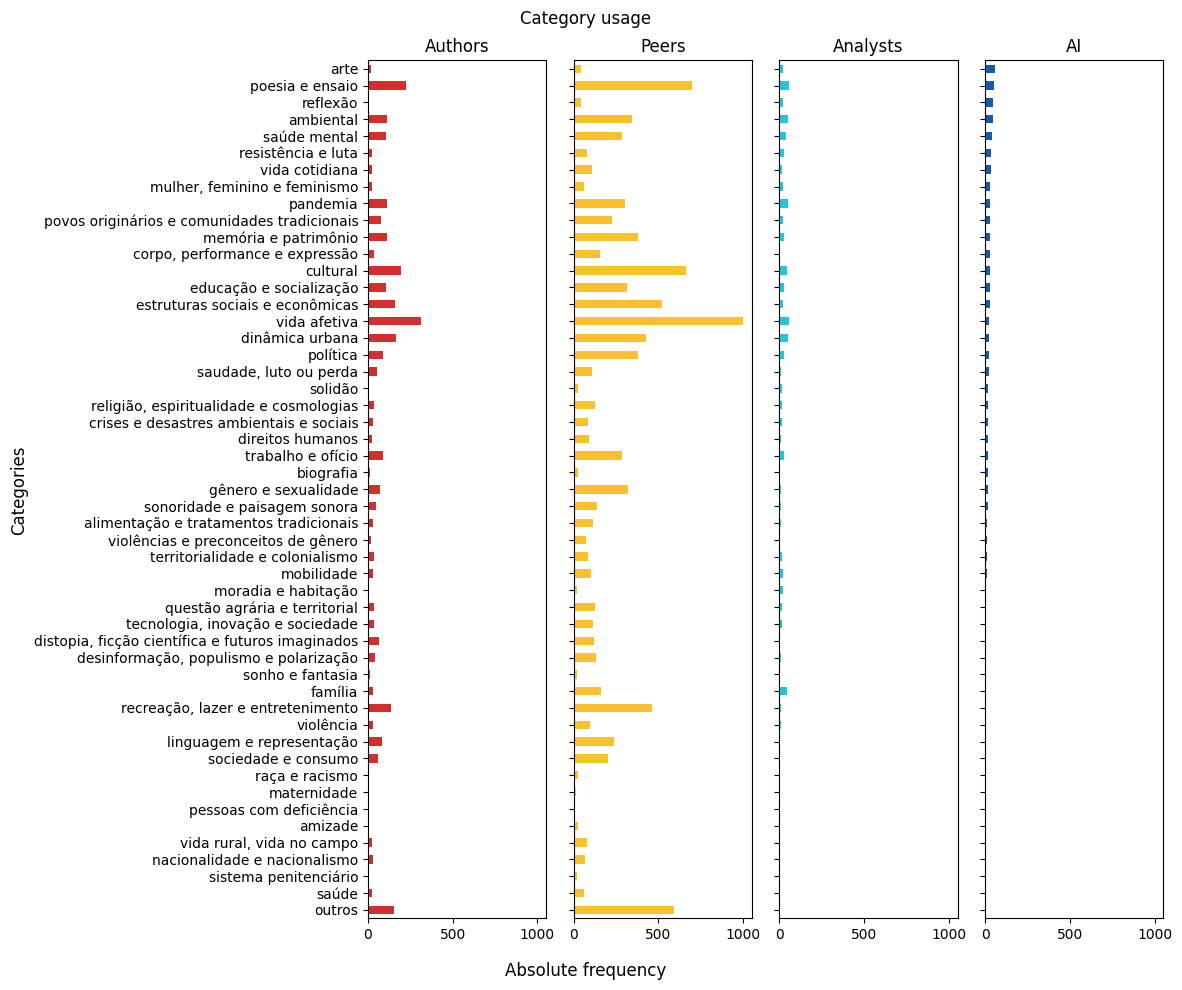

In [128]:
fig, axes = plt.subplots(1,4, sharey=True, sharex=True, figsize=(12,10))

category_counts_sorted = category_counts.T.sort_values(by='AI', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_sorted.columns, axes.flat)):
    category_counts_sorted[dimension].plot(kind='barh', ax = ax, color=colors_single[idx])
    ax.set_ylabel('')
    ax.set_title(dimension)
    
fig.suptitle('Category usage')
fig.supxlabel('Absolute frequency')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_usage_frequency.png', dpi = 300)
plt.show()

category_counts_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_usage_frequency.xlsx')

* Relative frequency

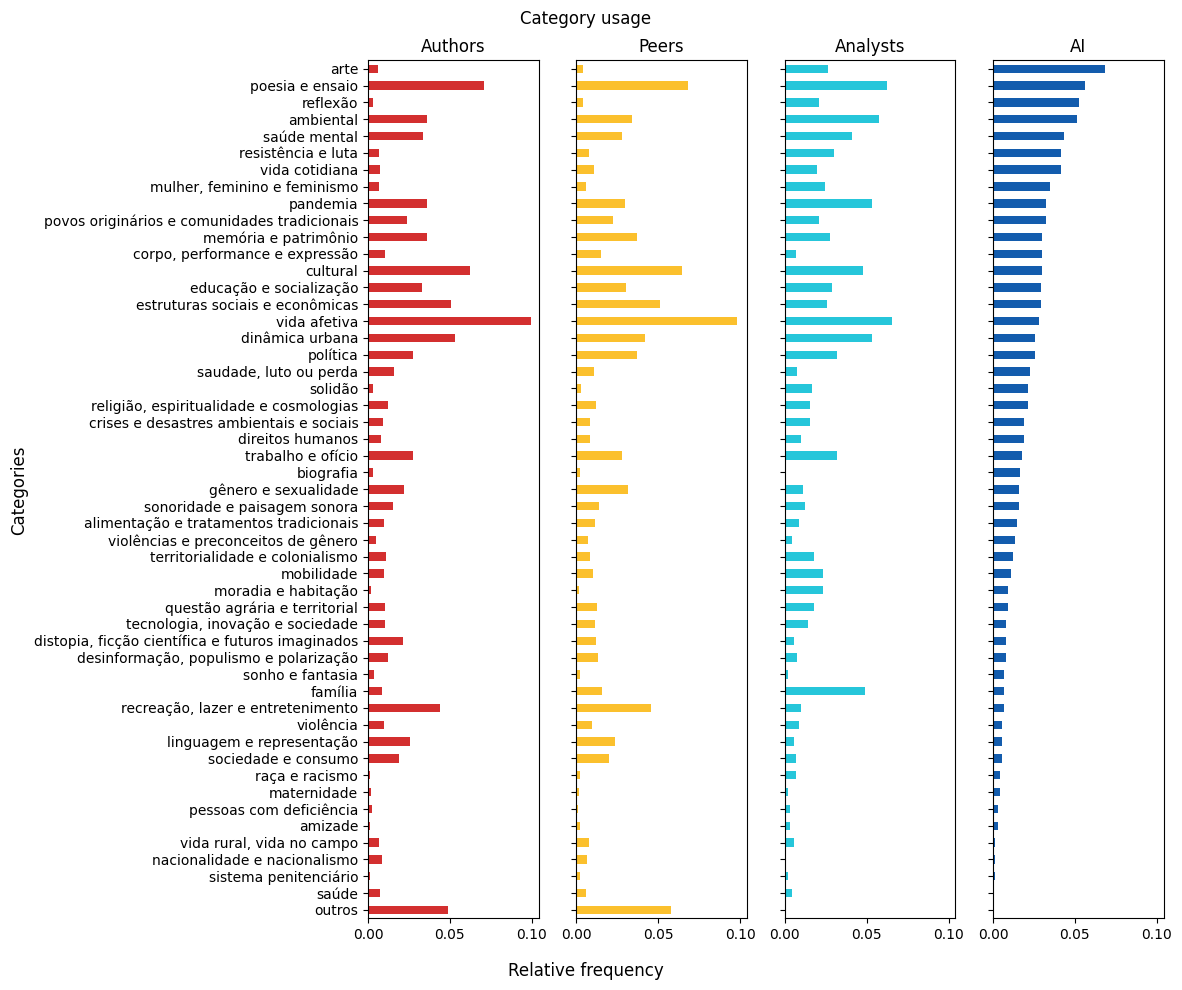

In [129]:
category_counts_normalized = category_counts.div(category_counts.sum(axis=1), axis = 0)

fig, axes = plt.subplots(1,4, sharey=True, sharex=True, figsize=(12,10))

category_counts_normalized_sorted = category_counts_normalized.T.sort_values(by='AI', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_normalized_sorted.columns, axes.flat)):
    category_counts_normalized_sorted[dimension].plot(kind='barh', ax = ax, color=colors_single[idx])
    ax.set_ylabel('')
    ax.set_title(dimension)
    
fig.suptitle('Category usage')
fig.supxlabel('Relative frequency')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_usage_frequency_relative.png', dpi = 300)
plt.show()

category_counts_normalized_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_usage_frequency_relative.xlsx')

* Quantitative bias

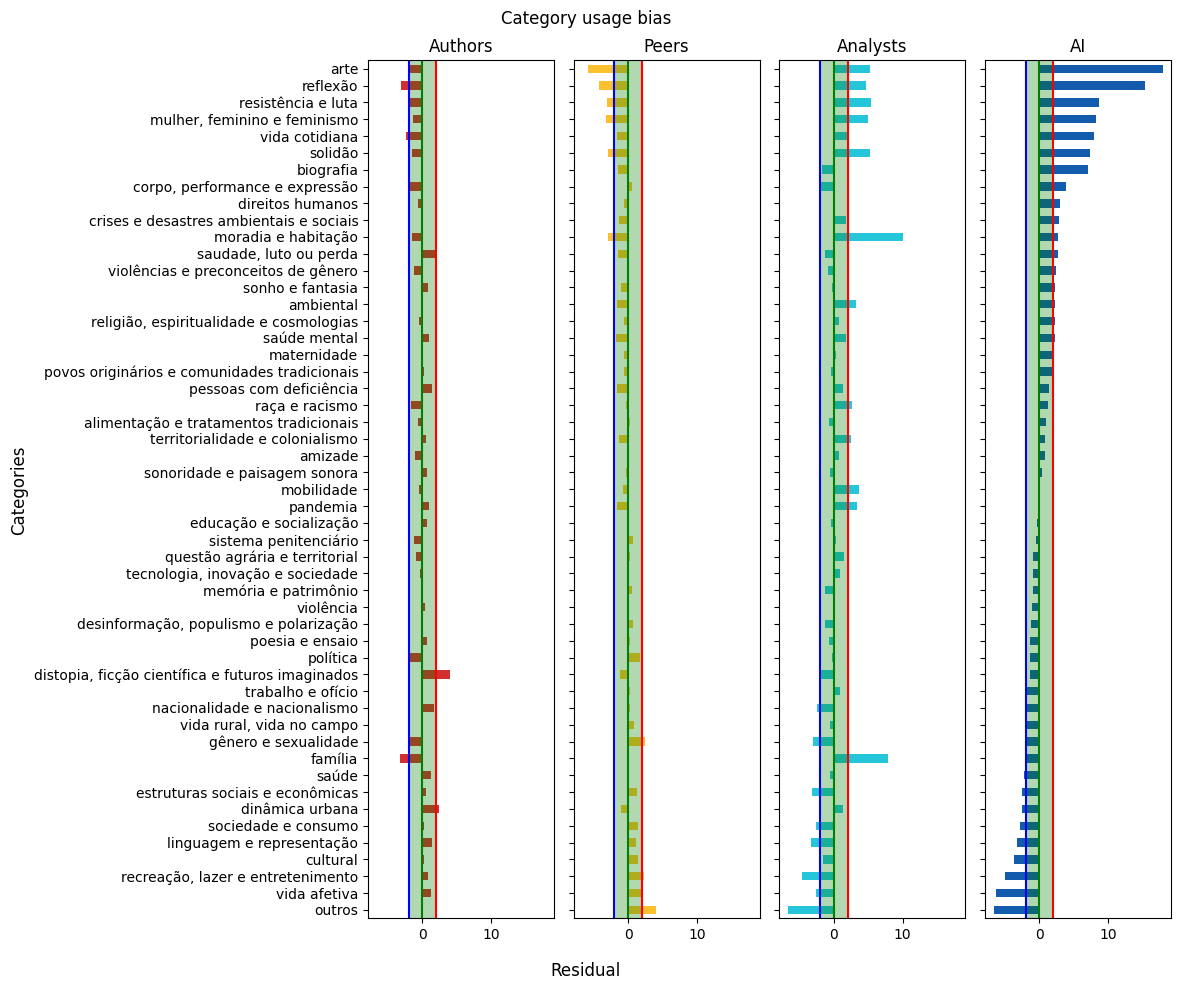

In [130]:
residuals_sorted = residuals.T.sort_values(by='AI', na_position='first')

fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

for idx, (dimension, ax) in enumerate(zip(residuals_sorted.columns, axes.flat)):

    residuals_sorted[dimension].plot(kind='barh', ax = ax, color = colors_single[idx])

    ax.axvline(0, color = 'green')
    ax.axvspan(-2,2, alpha = 0.3, color='green', linewidth=0)
    ax.axvline(-2, color = 'blue', linewidth=1.5) #residuals_sorted.min().min()
    ax.axvline(2, color = 'red', linewidth=1.5) # residuals_sorted.max().max()

    ax.set_ylabel('')
    ax.set_title(dimension)

fig.suptitle('Category usage bias')
fig.supxlabel('Residual')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_bias.png', dpi = 300)
plt.show()

residuals_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_bias.xlsx')

In [131]:
_df_authors = df_authors.reset_index().copy()

_df_authors['rater_index'] = (_df_authors.groupby(['film_id', 'Analista', column_author_level]).cumcount() + 1)

df_authors_meso_wide = (_df_authors
                        .set_index(['film_id', 'Analista', column_author_level, 'rater_index'])[column_themes]
                        .unstack(['Analista', column_author_level,'rater_index']))

df_authors_meso_wide.columns = df_authors_meso_wide.columns.reorder_levels([1, 2, 3, 0])
df_authors_meso_wide.columns = df_authors_meso_wide.columns.set_names(['supervisor', 'score', 'rater', 'level'])
df_authors_meso_wide = df_authors_meso_wide.sort_index(axis=1, level = 0)

In [132]:
long_frames = []

dfs_meso_agents = dfs.copy()

dfs_meso_agents['Authors'] = df_authors_meso_wide

for dimension, df in dfs_meso_agents.items():
    tmp = df.copy()
    tmp = tmp.reset_index()
    tmp = tmp.rename(columns={tmp.columns[0]: "film_id"})
    
    flat_cols = []
    for col in tmp.columns:
        if any(str(c) == "film_id" for c in col):
            flat_cols.append("film_id")
        else:
            parts = [str(c) for c in col if c not in (None, "", "nan")]
            flat_cols.append("_".join(parts))
    tmp.columns = flat_cols

    label_cols = [c for c in tmp.columns if c != 'film_id']

    tmp_long = tmp.melt(
        id_vars="film_id",
        value_vars=label_cols,
        var_name="rater_level",
        value_name="level")
    

    if dimension in ['Analysts', 'AI']:
        agents = [f'{dimension} {col.split('_')[0]}' for col in tmp_long['rater_level']]
    elif dimension == 'Peers':
        agents = [dimension] * len(tmp_long)
    else:
        agents = [f'{dimension} {' Score '.join(col.split('_')[:2])}' for col in tmp_long['rater_level']]

    tmp_long["group"] = agents
    tmp_long = tmp_long.dropna(subset=["level"])

    long_frames.append(tmp_long)

df_long = pd.concat(long_frames, ignore_index=True)

category_counts_agents = (
    df_long
    .groupby(["group", "level"])
    .size()
    .unstack(fill_value=0)
)


#### By agent

In [133]:
idx = category_counts_agents.index.to_series()

mask_authors = idx.str.contains('Authors', case=False, na=False)

level_from_idx = idx.str.extract(r'(Score\s+[135])')[0]

df_authors_avg = category_counts_agents[mask_authors].copy()
df_authors_avg['level_tmp'] = level_from_idx[mask_authors]

authors_avg = (
    df_authors_avg
    .groupby('level_tmp')
    .mean(numeric_only=True)
)
authors_avg = authors_avg.astype(int)
authors_avg.index = [f'Authors {lvl}' for lvl in authors_avg.index]

df_others = category_counts_agents[~mask_authors].copy()
df_others = df_others.loc[['Peers', 'Analysts SV','Analysts VS', 'AI ChatGPT', 'AI Gemini']]

category_counts_agents = pd.concat([authors_avg, df_others], axis=0)

* Absolute frequency

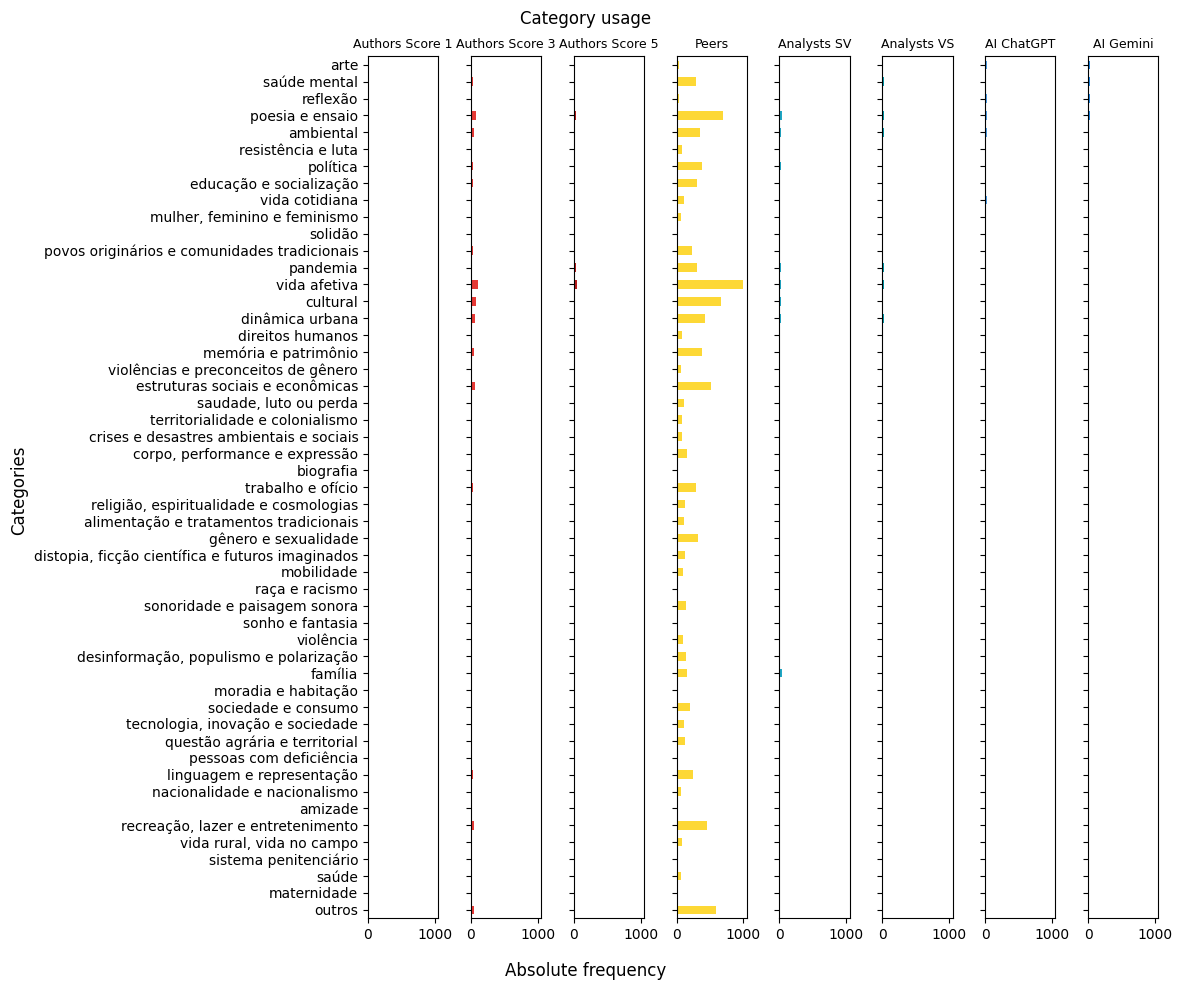

In [134]:
fig, axes = plt.subplots(1,len(category_counts_agents.T.columns), sharey=True, sharex=True, figsize=(12,10))

category_counts_agents_sorted = category_counts_agents.T.sort_values(by='AI Gemini', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_agents_sorted.columns, axes.flat)):
    category_counts_agents_sorted[dimension].plot(kind='barh', ax = ax, color=colors_agents[idx])
    ax.set_ylabel('')
    ax.set_title(dimension, fontsize=9)
    
fig.suptitle('Category usage')
fig.supxlabel('Absolute frequency')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_usage_frequency_agents.png', dpi = 300)
plt.show()

category_counts_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_usage_frequency_agents.xlsx')

* Relative frequency

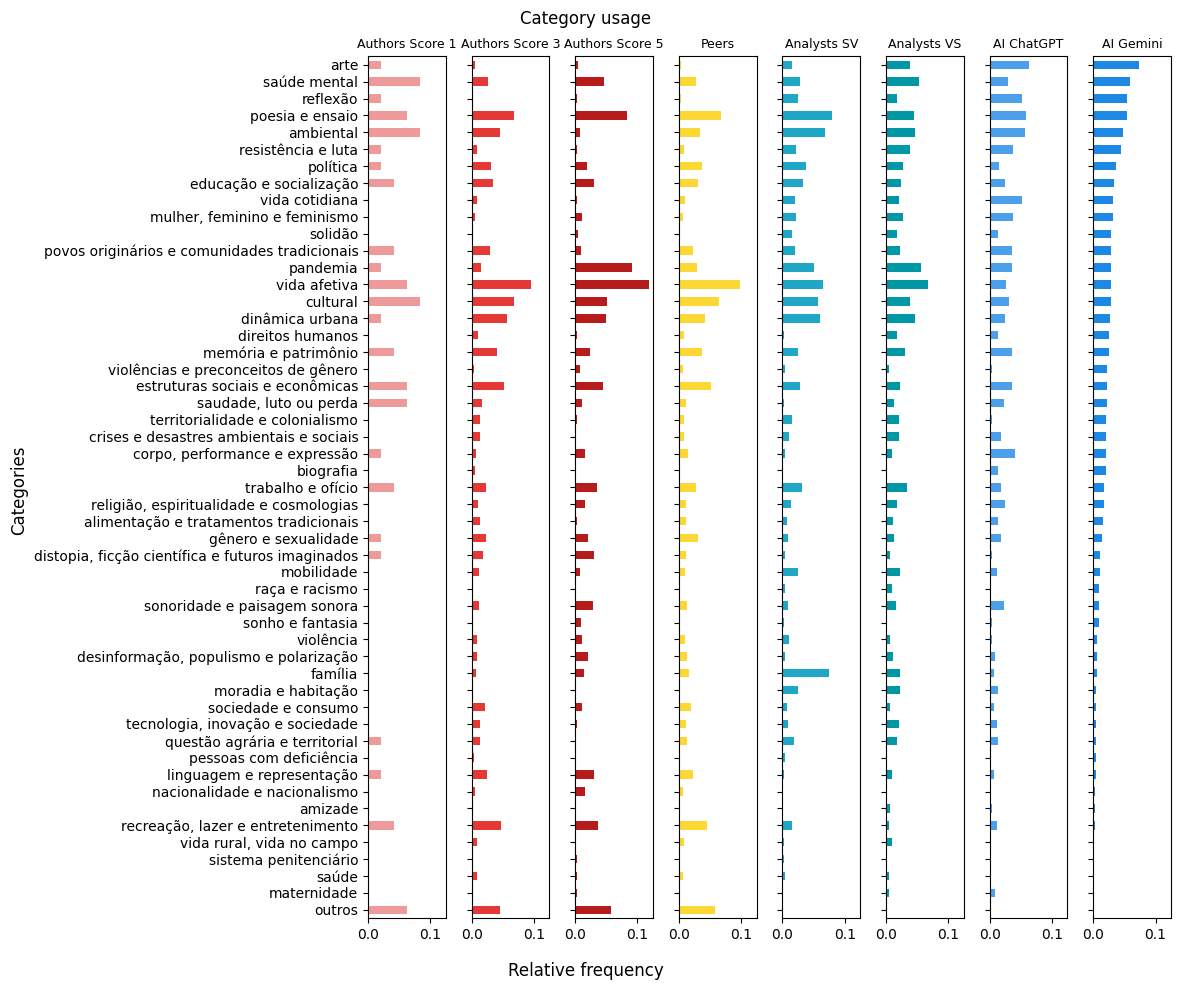

In [135]:
category_counts_agents_normalized = category_counts_agents.div(category_counts_agents.sum(axis=1), axis = 0)

fig, axes = plt.subplots(1,len(category_counts_agents.T.columns), sharey=True, sharex=True, figsize=(12,10))

category_counts_agents_normalized_sorted = category_counts_agents_normalized.T.sort_values(by='AI Gemini', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_agents_normalized_sorted.columns, axes.flat)):
    category_counts_agents_normalized_sorted[dimension].plot(kind='barh', ax = ax, color=colors_agents[idx])
    ax.set_ylabel('')
    ax.set_title(dimension, fontsize=9)
    
fig.suptitle('Category usage')
fig.supxlabel('Relative frequency')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_usage_frequency_relative_agents.png', dpi = 300)
plt.show()

category_counts_agents_normalized_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_usage_frequency_relative_agents.xlsx')

* Category usage bias by agent is obtained by calculation of chi-square values.

In [136]:
chi2, p, dof, expected = chi2_contingency(category_counts_agents)

expected = pd.DataFrame(
    expected,
    index=category_counts_agents.index,
    columns=category_counts_agents.columns,
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

residuals_agents = (category_counts_agents - expected) / np.sqrt(expected)

Chi-square statistic: 2197.246589193088
Degrees of freedom: 350
p-value: 1.7723568102149443e-264


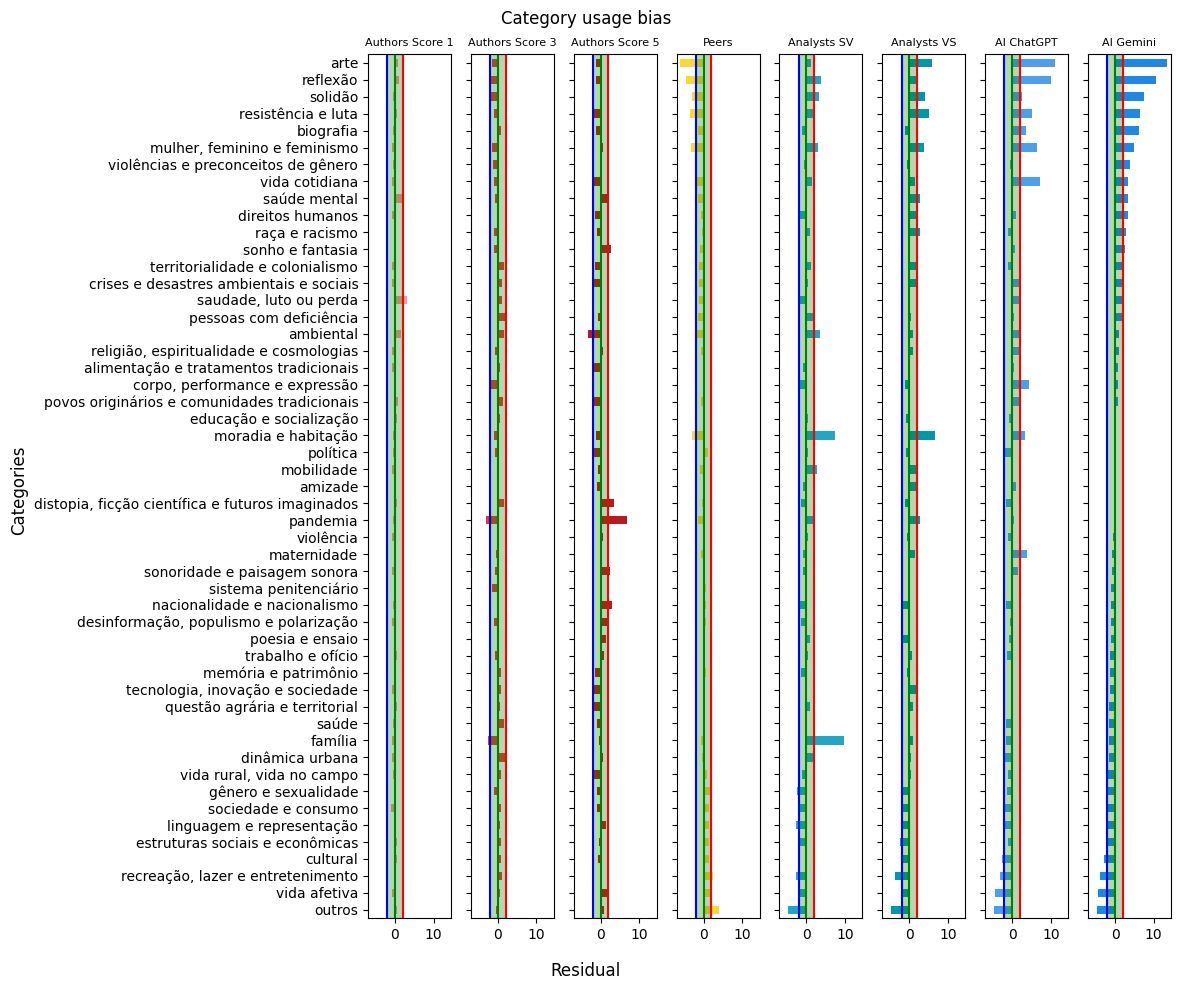

In [137]:
residuals_agents_sorted = residuals_agents.T.sort_values(by='AI Gemini', na_position='first')

fig, axes = plt.subplots(1,len(residuals_agents_sorted.columns), sharex=True, sharey=True, figsize=(12,10))

for idx, (dimension, ax) in enumerate(zip(residuals_agents_sorted.columns, axes.flat)):

    residuals_agents_sorted[dimension].plot(kind='barh', ax = ax, color = colors_agents[idx])

    ax.axvline(0, color = 'green')
    ax.axvspan(-2,2, alpha = 0.3, color='green')
    ax.axvline(-2, color = 'blue', linewidth=1.5) #residuals_agents_sorted.min().min()
    ax.axvline(2, color = 'red', linewidth=1.5) #residuals_agents_sorted.max().max()

    ax.set_ylabel('')
    ax.set_title(dimension, fontsize=8)

fig.suptitle('Category usage bias')
fig.supxlabel('Residual')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_bias_agents.png', dpi = 300)
plt.show()

residuals_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_bias_agents.xlsx')

### Film category entropy

In [138]:
df_all = pd.concat([df for df in dfs.values()], axis = 1)

df_entropy = engineering.per_film_entropy(df_all)
df_entropy.set_index('film_id', inplace =True)
df_entropy.to_excel(f'{RESULTS_TABLES_DIR}/meso_entropy.xlsx')

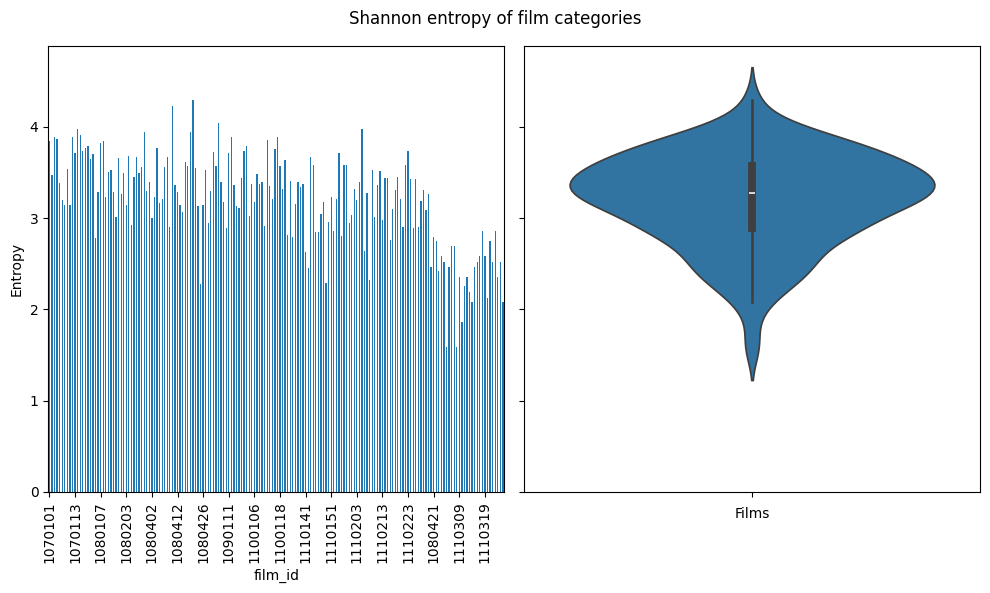

In [139]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1,2, figsize = (10,6), sharey=True)

df_entropy['entropy'].plot(kind='bar', ax = ax[0])
sns.violinplot(data=df_entropy, y='entropy', ax = ax[1])
ax[0].xaxis.set_major_locator(MaxNLocator(nbins=20))
ax[0].set_ylabel('Entropy')
ax[1].set_xlabel('Films')
fig.suptitle('Shannon entropy of film categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_per_film_entropy.png', dpi = 300)
plt.show()

#### Film entropy vs micro level 

C:\Users\User01\AppData\Local\Temp\ipykernel_57416\1550742990.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


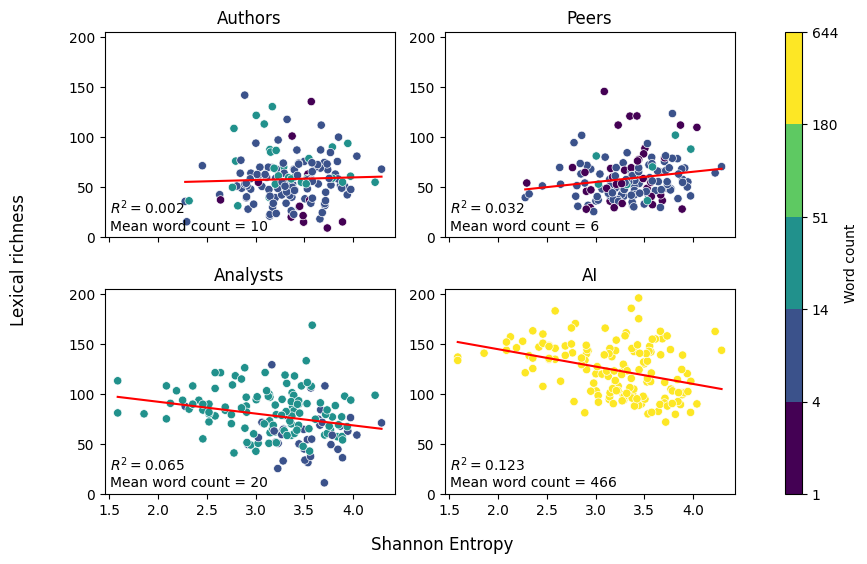

C:\Users\User01\AppData\Local\Temp\ipykernel_57416\1550742990.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


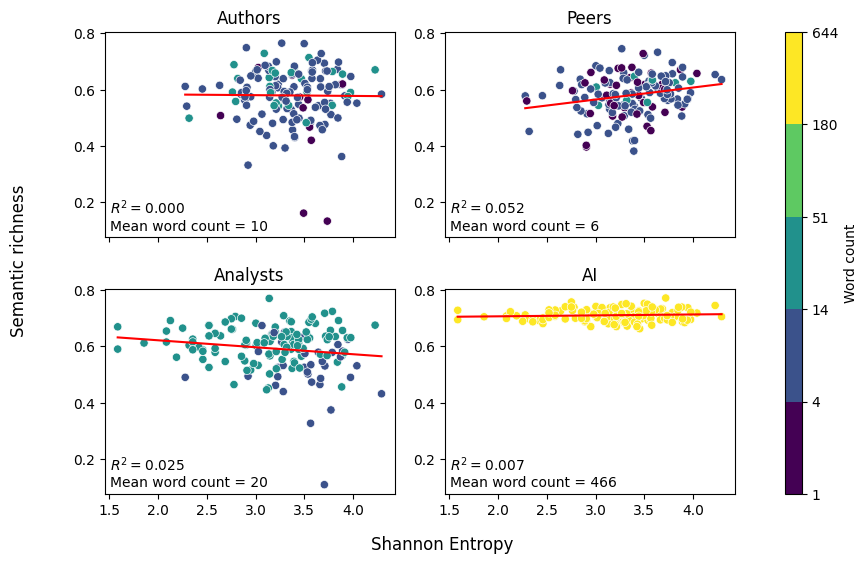

In [140]:
labels =[1,2,3,4,5]

for richness in ['lexical_richness', 'semantic_richness']:
    if richness == 'lexical_richness':
        label = 'Lexical richness'
    else:
        label = 'Semantic richness'

    fig = plt.figure(figsize=(9, 6))

    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.06], height_ratios = [1,1], hspace=0.25, wspace=0.25)

    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[0,1], sharex=ax1, sharey=ax1)
    ax3 = fig.add_subplot(gs[1,0], sharex=ax1, sharey=ax1)
    ax4 = fig.add_subplot(gs[1,1], sharex=ax1, sharey=ax1)

    ax1.tick_params(labelbottom=False)
    ax2.tick_params(labelbottom=False)

    axes = [ax1,ax2,ax3,ax4]

    df = df_micro_richness.xs(richness, level=0, axis = 1)

    for dimension, ax in zip(df.columns, axes):

        #df_merge = pd.merge(df_entropy['entropy'], df[dimension], on = 'film_id')
        
        df_merge = pd.concat([df_entropy['entropy'], df[dimension], df_bins[f'{dimension}_N']], axis = 1)

        df_merge.rename(columns={dimension : label}, inplace=True)
        mean_word_count = df_word_counts[f'{dimension}_N'].mean()
        
        sns.scatterplot(data=df_merge, 
                        x='entropy', 
                        y=label, 
                        hue=f'{dimension}_color',
                        hue_order=labels,
                        palette=palette, 
                        legend=False,
                        ax = ax)
        
        ax.set_title(dimension)
        ax.set_xlabel('')
        ax.set_ylabel('')

        x_range, y_pred, r2 = engineering.get_fitted(df_merge, 'entropy', label)

        ax.plot(x_range, y_pred, color='red')

        locs = 0.95 if richness == 'lexical_richess' else 0.02

        ax.text(
                0.02, locs,
                f"$R^2 = {r2:.3f}$\nMean word count = {mean_word_count:.0f}",
                transform=ax.transAxes,
                fontsize=10,
                va='bottom',
                ha='left'
            )
    
    cax = fig.add_subplot(gs[:, 2])

    sm = ScalarMappable(norm=norm_word, cmap=cmap_word)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)

    # Ticks at the bin edges, label nicely
    cbar.set_ticks(bins)
    cbar.set_ticklabels([f"{b:.0f}" for b in bins])
    cbar.set_label("Word count")

    fig.supylabel(label)
    fig.supxlabel('Shannon Entropy')
    fig.tight_layout()
    fig.savefig(f'{RESULTS_FIGURES_DIR}/{richness}_micro_vs_meso.png', dpi = 300)
    plt.show()


## MCA

In [141]:
top_categories = pd.read_excel(f'{DATA_RAW_DIR}/Dados Integrados/v4-NOVO-TabelaSimples de Temas por Filmes e Agentes.xlsx', sheet_name=['An-Analistas Ambos', 'Au-Autores1a5', 'Pa-Pares', 'IA-IAs'])

In [142]:
# df = top_categories['An-Analistas Ambos'][['ID Filme', 'Nome Filme']].copy()
# df['film_id'] = df['ID Filme'].astype(str)
# df['title'] = df['Nome Filme']
# df_titles = df[['film_id','title']]

In [143]:
dimension_map = {'An-Analistas Ambos' : 'Analystas',
                 'Au-Autores1a5' : 'Authors',
                 'Pa-Pares' : 'Peers',
                 'IA-IAs' : 'AI'}

dfs_categories = {}

for dimension, _df in top_categories.items():
    df = _df.copy()
    df['film_id'] = df['ID Filme']
    df.set_index('film_id', inplace=True)
    df['category'] = df['Categoria-Tema'].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()
    dfs_categories[dimension_map[dimension]] = df[['category']]

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


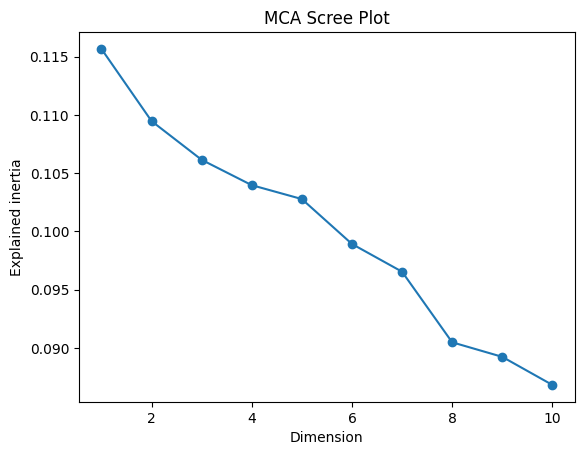

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



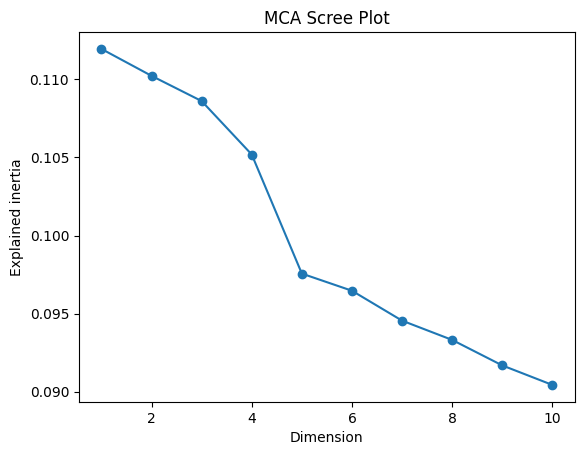

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



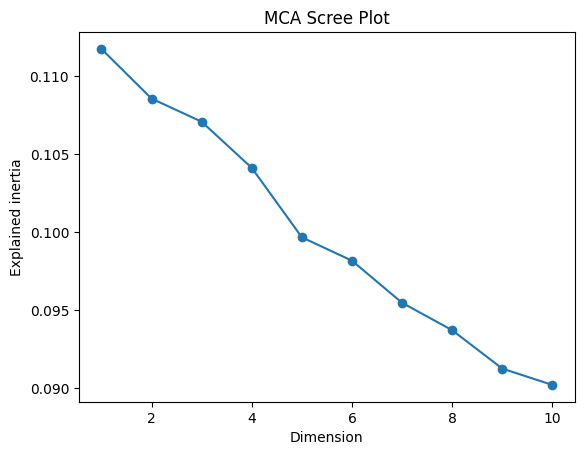

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



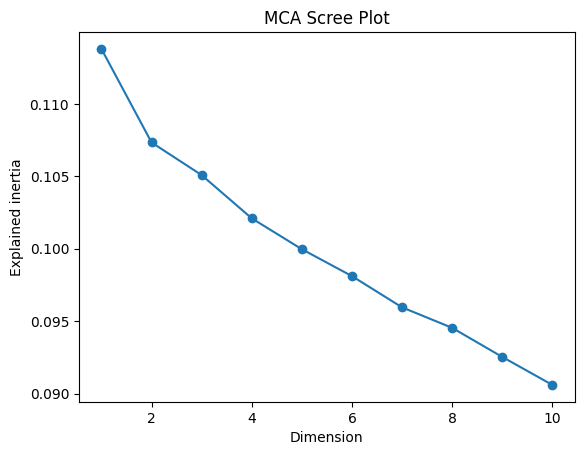

In [144]:
file_name = 'test'

for dimension, _df in dfs.items():
    df = _df.copy()
    #df = df.xs('Tema 0', level=-1, axis = 1)
    df.columns = df.columns.map(lambda tup: "_".join(map(str, tup)))

    for col in df.columns:
        df[col] = df[col].astype('category')

    df.index = df.index.astype(int)

    fig = engineering.get_mca(df, dimension, df_titles)
    
    fig.write_html(f"{RESULTS_FIGURES_DIR}/mca_{dimension}_{file_name}.html", include_plotlyjs="cdn")
    fig.show()
    

    



In [145]:
_dfs_prep_mca = dfs_meso_agents.copy()

_df = _dfs_prep_mca['Authors'].copy()
_df.columns = pd.MultiIndex.from_tuples([
        (f"{l0}_{l1}_{l2}", l3) for l0, l1, l2, l3 in _df.columns], names=["rater", _df.columns.names[3]])

_dfs_prep_mca['Authors'] = _df

_df = _dfs_prep_mca['Peers'].copy()
_df.columns = pd.MultiIndex.from_tuples([
        (f"{l0}_{l1}", l2) for l0, l1, l2 in _df.columns], names=["rater", _df.columns.names[2]])

_dfs_prep_mca['Peers'] = _df

dfs_prep_mca = pd.concat({k:v for k,v in _dfs_prep_mca.items()}, axis = 1)
dfs_prep_mca

Authors                                           \
rater                    SV_1_1                                   SV_3_1   
level                    Tema 0           Tema 2  Tema 3          Tema 0   
film_id                                                                    
1070101                     NaN              NaN     NaN             NaN   
1070102                     NaN              NaN     NaN  vida cotidiana   
1070103                     NaN              NaN     NaN             NaN   
1070105  saudade, luto ou perda  poesia e ensaio  outros             NaN   
1070106                     NaN              NaN     NaN             NaN   
...                         ...              ...     ...             ...   
1110322                     NaN              NaN     NaN             NaN   
1110323                     NaN              NaN     NaN             NaN   
1110324                     NaN              NaN     NaN             NaN   
1110325                     NaN              NaN     NaN             NaN   
1110326                     NaN              NaN     NaN             NaN   

                                                                       ...  \
rater                                     SV_3_2               SV_3_3  ...   
level             Tema 2           Tema 3 Tema 0 Tema 2 Tema 3 Tema 0  ...   
film_id                                                                ...   
1070101              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1070102  dinâmica urbana  poesia e ensaio    NaN    NaN    NaN    NaN  ...   
1070103              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1070105              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1070106              NaN              NaN    NaN    NaN    NaN    NaN  ...   
...                  ...              ...    ...    ...    ...    ...  ...   
1110322              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1110323              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1110324              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1110325              NaN              NaN    NaN    NaN    NaN    NaN  ...   
1110326              NaN              NaN    NaN    NaN    NaN    NaN  ...   

                                  Analysts  \
rater                                   SV   
level                               Tema 3   
film_id                                      
1070101          linguagem e representação   
1070102  recreação, lazer e entretenimento   
1070103                         mobilidade   
1070105                            família   
1070106                           pandemia   
...                                    ...   
1110322                            família   
1110323                               arte   
1110324                     vida cotidiana   
1110325            pessoas com deficiência   
1110326                   direitos humanos   

                                                 \
rater                                        VS   
level                                    Tema 0   
film_id                                           
1070101                    gênero e sexualidade   
1070102                         dinâmica urbana   
1070103                     moradia e habitação   
1070105                                 família   
1070106            mulher, feminino e feminismo   
...                                         ...   
1110322  alimentação e tratamentos tradicionais   
1110323                      resistência e luta   
1110324                               violência   
1110325                            saúde mental   
1110326  desinformação, populismo e polarização   

                                                 \
rater                                             
level                                    Tema 2   
film_id                                           
1070101         territorialidade e colonialismo   


c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



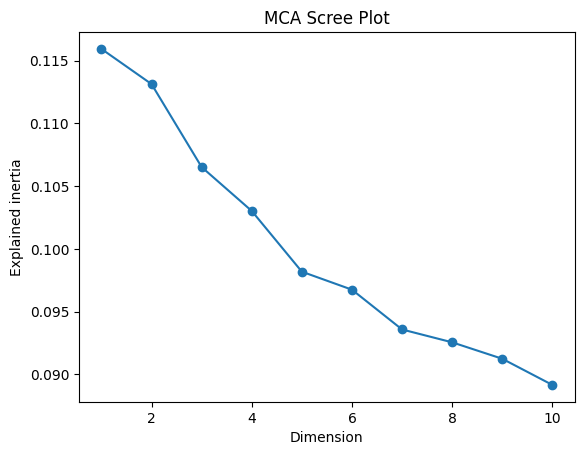

In [146]:
df_all = pd.concat([df.copy() for df in dfs.values()], axis = 1)

df_all.columns = df_all.columns.map(lambda tup: "_".join(map(str, tup)))

file_name = 'test_all'

for col in df_all.columns:
    df_all[col] = df_all[col].astype('category')

fig = engineering.get_mca(df_all, 'all', df_titles)

fig.write_html(f"{RESULTS_FIGURES_DIR}/mca_all_{file_name}.html", include_plotlyjs="cdn")
fig.show()

## Identity Values

In [204]:
df_identities = pd.read_excel(f'{DATA_RAW_DIR}/Dados Identidades/Dados de Input Identidades/PAID_01_DadosParticipantes_Identidade.xlsx')

In [205]:
df_identities['film_id'] = df_identities['ID_OfGrPart'].str.split("-", n=1).str[0].str.strip().astype(int)
df_identities['rater_id'] = df_identities['ID_OfGrPart'].str.split("-", n=1).str[1].str.strip().astype(str)

df_identities = df_identities.set_index('ID_OfGrPart')

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [206]:
df_identities = df_identities[df_identities['film_id'] > 1069000]

### Correlation Analysis

### Machine Learning

In [207]:
df_themes_list = []

for theme in column_themes:

    df_theme = df_authors_meso_wide.xs(theme, axis = 1, level = -1)

    list_themes = df_theme.apply(lambda row : row.dropna().unique(), axis = 1)

    list_themes.name = theme

    df_themes_list.append(list_themes)

df_themes = pd.concat(df_themes_list, axis = 1)
df_themes

,Tema 0,Tema 2,Tema 3
film_id,,,
1070101,"[violências e preconceitos de gênero, gênero e...","[gênero e sexualidade, violências e preconceit...","[estruturas sociais e econômicas, violências e..."
1070102,"[vida cotidiana, dinâmica urbana, vida afetiva...","[dinâmica urbana, poesia e ensaio, pandemia, s...","[poesia e ensaio, mobilidade, vida afetiva, re..."
1070103,"[poesia e ensaio, arte, sonoridade e paisagem ...","[saúde mental, vida afetiva, poesia e ensaio, ...","[outros, direitos humanos, cultural, vida afet..."
1070105,"[saudade, luto ou perda, memória e patrimônio,...","[poesia e ensaio, memória e patrimônio, famíli...","[outros, vida afetiva, poesia e ensaio, cultur..."
1070106,"[mulher, feminino e feminismo, educação e soci...","[gênero e sexualidade, estruturas sociais e ec...","[trabalho e ofício, educação e socialização, v..."
...,...,...,...
1110226,"[cultural, dinâmica urbana, estruturas sociais...","[dinâmica urbana, linguagem e representação, a...","[poesia e ensaio, estruturas sociais e econômi..."
1110227,"[poesia e ensaio, memória e patrimônio, vida a...","[vida afetiva, estruturas sociais e econômicas...","[dinâmica urbana, outros, poesia e ensaio, rec..."
1110228,"[trabalho e ofício, vida afetiva, saúde mental]","[poesia e ensaio, saúde mental, vida afetiva]","[vida afetiva, poesia e ensaio, recreação, laz..."


In [ ]:
# from collections import Counter

# label_cols = ['Tema 0'] #, 'Tema 2', 'Tema 3']

# def to_list(x):
#     # Treat missing as empty
#     if x is None or (isinstance(x, float) and np.isnan(x)):
#         return []
#     # If it's already a list/tuple/set, make it a list
#     if isinstance(x, (list, tuple, set)):
#         return list(x)
#     # If it's a numpy array, convert safely
#     if isinstance(x, np.ndarray):
#         return x.tolist()
#     # If it's a scalar (e.g., a single label), wrap it
#     return [x]

# def top3_row(row):
#     labels = []
#     for c in label_cols:
#         labels.extend(to_list(row[c]))
#     return [lab for lab, _ in Counter(labels).most_common(3)]

# df_themes["top_3_themes"] = df_themes.apply(top3_row, axis=1)

In [210]:
df_input = df_identities.join(df_themes, how='left', on = 'film_id')

<Axes: >

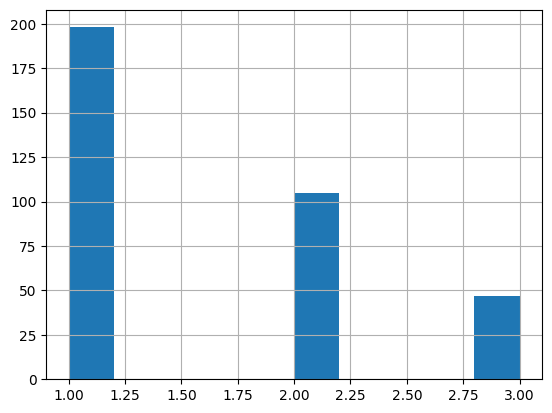

In [211]:
df_input['rater_id'].value_counts().hist()

In [ ]:
#df_input = df_input.dropna(subset='Tema 0')
df_input = df_input.dropna(subset='top_3_themes')

In [224]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df_input["Tema 0"])
#Y = mlb.fit_transform(df_input['top_3_themes'])
label_names = mlb.classes_

In [225]:
from sklearn.model_selection import GroupKFold

group_col = "film_id"
rater_col = "rater_id"

feature_cols = [c for c in df_input.columns if c not in [rater_col, group_col, 'Tema 0', 'Tema 2', 'Tema 3', 'top_3_themes']]
X = df_input[feature_cols]

import re

def sanitize(col):
    col = col.strip()
    col = re.sub(r"[\[\]<]", "", col)   # remove forbidden chars
    col = re.sub(r"\s+", "_", col)      # spaces → underscores
    return col

X = X.rename(columns={c: sanitize(c) for c in X.columns})

groups = df_input[rater_col]
cv = GroupKFold(n_splits=5)

In [159]:
import xgboost as xgb

def make_model(scale_pos_weight):
    return xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=1200,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        min_child_weight=2,
        gamma=0.0,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

In [226]:
from sklearn.metrics import f1_score

Y_true_all = []
Y_pred_all = []
models = []

for train_idx, val_idx in cv.split(X, Y, groups=groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    Y_train, Y_val = Y[train_idx], Y[val_idx]

    Y_pred = np.zeros_like(Y_val, dtype=float)

    for j, label in enumerate(label_names):
        y_tr = Y_train[:, j]
        y_va = Y_val[:, j]

        # skip labels with no positives in training
        if y_tr.sum() == 0:
            continue

        pos = y_tr.sum()
        neg = len(y_tr) - pos
        scale_pos_weight = neg / pos

        model = make_model(scale_pos_weight)
        model.fit(X_train, y_tr)

        models.append(model)

        Y_pred[:, j] = model.predict_proba(X_val)[:, 1]

    Y_true_all.append(Y_val)
    Y_pred_all.append(Y_pred)

Y_true = np.vstack(Y_true_all)
Y_pred = np.vstack(Y_pred_all)


In [227]:
from sklearn.metrics import precision_recall_curve

thresholds = []

for j in range(Y_true.shape[1]):
    precision, recall, th = precision_recall_curve(
        Y_true[:, j], Y_pred[:, j]
    )
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    thresholds.append(th[np.argmax(f1)])


In [228]:
Y_pred_bin = (Y_pred >= thresholds).astype(int)


In [229]:
from sklearn.metrics import f1_score, jaccard_score

print("Micro F1:", f1_score(Y_true, Y_pred_bin, average="micro"))
print("Macro F1:", f1_score(Y_true, Y_pred_bin, average="macro"))
print("Jaccard :", jaccard_score(Y_true, Y_pred_bin, average="samples"))


Micro F1: 0.19355264025314786
Macro F1: 0.1642872501050535
Jaccard : 0.10817139625044513


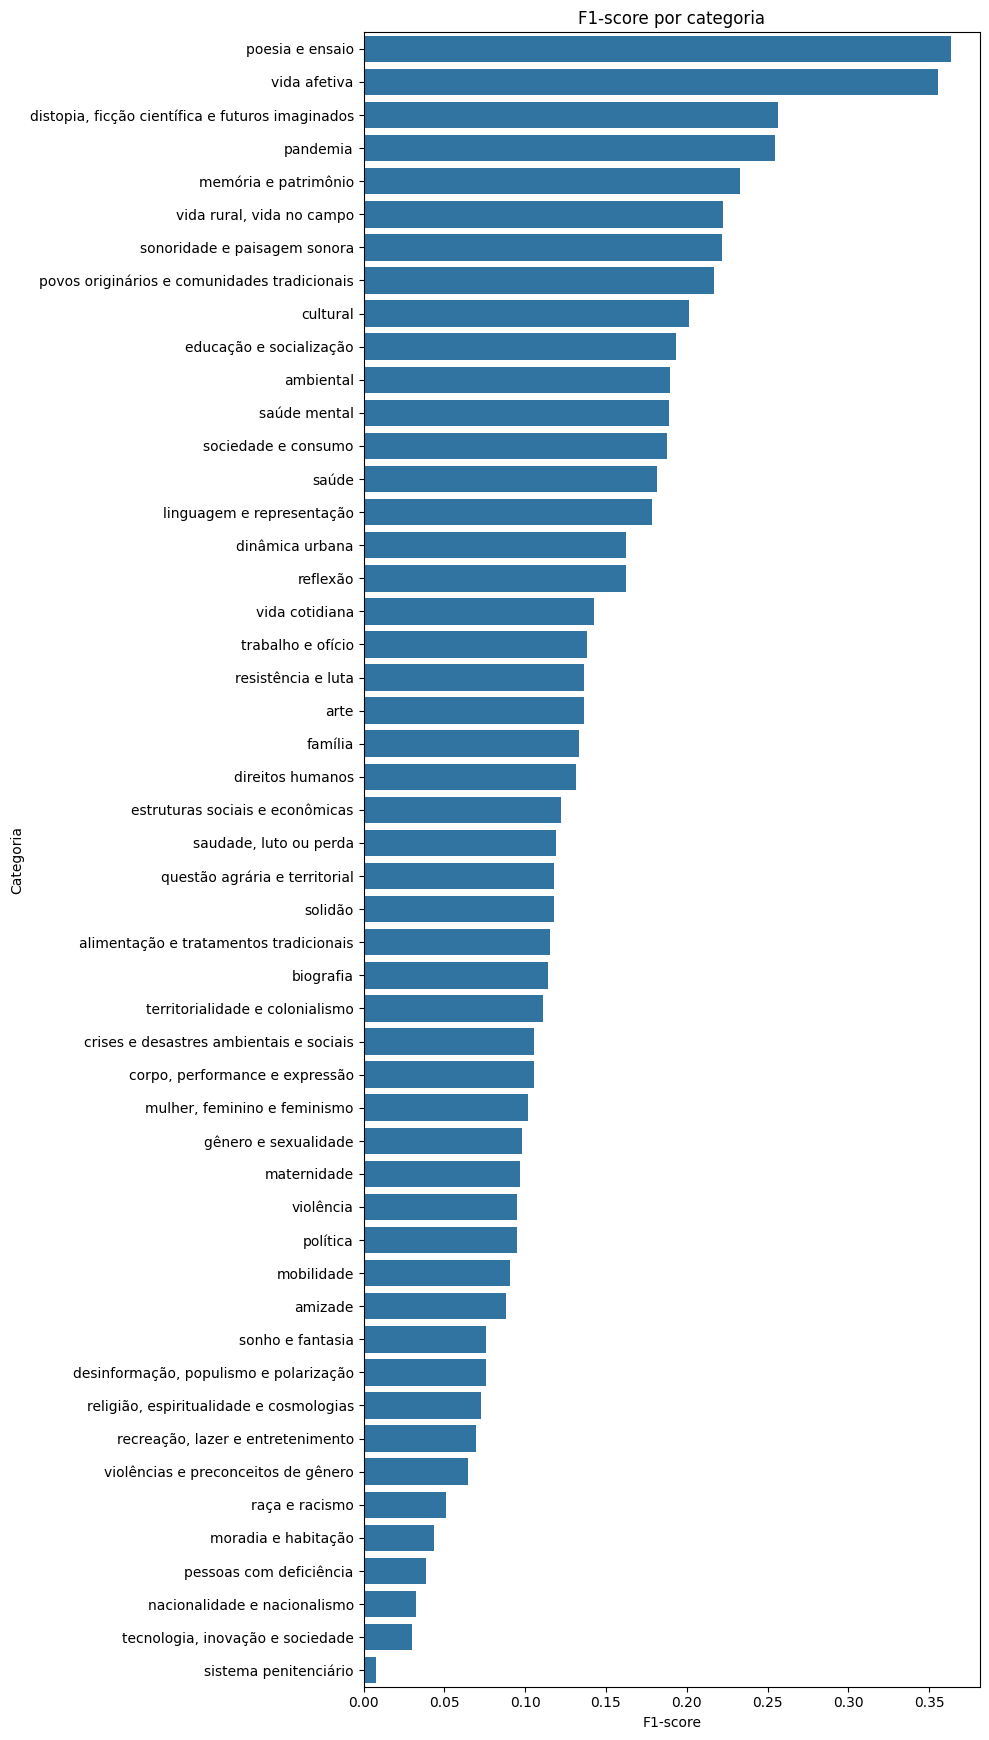

In [ ]:
df_f1 = pd.DataFrame({
    "label": label_names,
    "f1": [f1_score(Y_true[:, j], Y_pred_bin[:, j], zero_division=0)
           for j in range(Y_true.shape[1])],
    "prevalence": [Y_true[:, j].mean() for j in range(Y_true.shape[1])]  # fraction of films with label
}).sort_values("f1", ascending=False)

plt.figure(figsize=(10, max(6, 0.35 * len(df_f1))))
sns.barplot(data=df_f1, x="f1", y="label")
plt.title("F1-score por categoria")
plt.xlabel("F1-score")
plt.ylabel("Categoria")
plt.tight_layout()
plt.savefig(f'{RESULTS_FIGURES_DIR}/xgboost_f1_score.png', dpi= 300)
plt.show()

In [220]:
df_f1.to_excel(f'{RESULTS_TABLES_DIR}/xgboost_f1_score.xlsx')

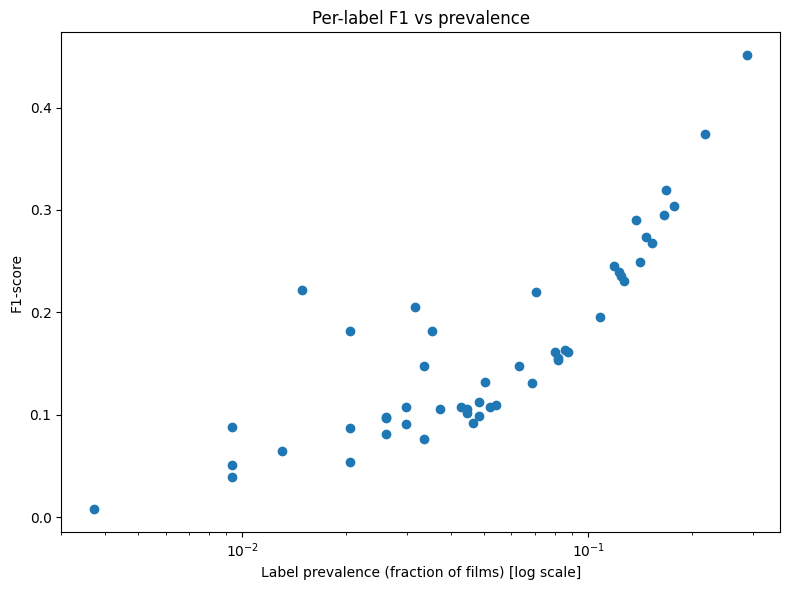

In [221]:

plt.figure(figsize=(8, 6))
plt.scatter(df_f1["prevalence"], df_f1["f1"])
plt.xscale("log")  # labels often long-tail; log makes this readable
plt.xlabel("Label prevalence (fraction of films) [log scale]")
plt.ylabel("F1-score")
plt.title("Per-label F1 vs prevalence")
plt.tight_layout()
plt.show()

In [221]:
import shap

mean_abs_per_label = []

for model in models:
    explainer = shap.TreeExplainer(model)
    X_explain = X
    sv = explainer.shap_values(X_explain)  # (n_samples, n_features)
    mean_abs_per_label.append(np.abs(sv).mean(axis=0))

# Average global importance across labels
global_importance = np.mean(mean_abs_per_label, axis=0)

imp = pd.Series(global_importance, index=X_explain.columns).sort_values()

In [223]:
imp.to_excel(f'{RESULTS_TABLES_DIR}/xgoobst_shap.xlsx')

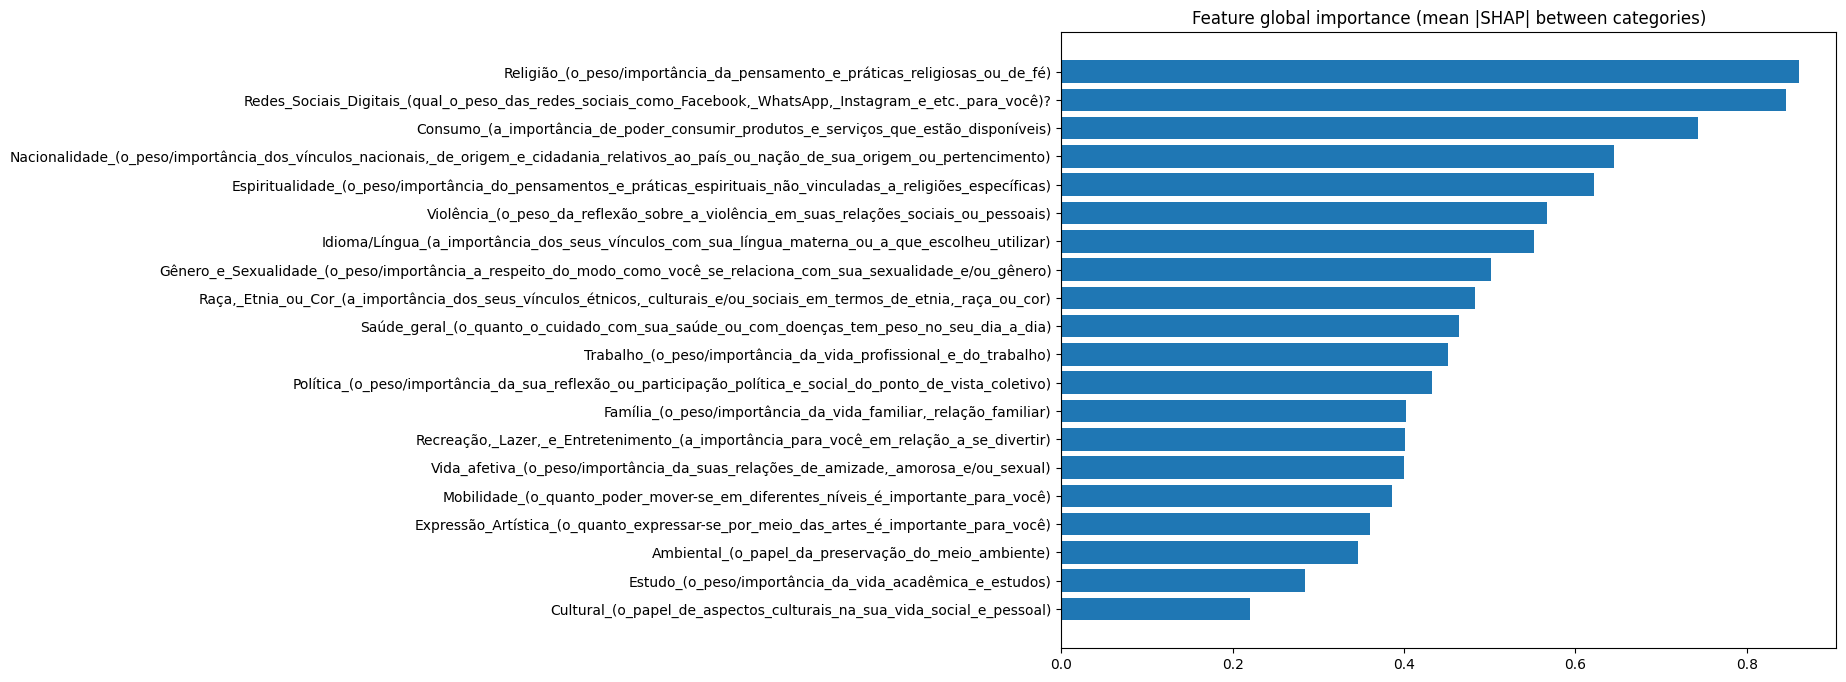

In [ ]:
imp = pd.Series(global_importance, index=X_explain.columns).sort_values()
plt.figure(figsize=(10,8))
plt.barh(imp.index, imp.values)
plt.title("Feature global importance (mean |SHAP| between categories)")
#plt.tight_layout()
plt.savefig(f'{RESULTS_FIGURES_DIR}/xgboost_shap.png', bbox_inches="tight", dpi = 300)
plt.show()

In [233]:
df_f1

,label,f1,prevalence
25,poesia e ensaio,0.363296,0.210428
45,vida afetiva,0.355556,0.210428
11,"distopia, ficção científica e futuros imaginados",0.256684,0.119181
23,pandemia,0.254480,0.139665
18,memória e patrimônio,0.232715,0.130354
47,"vida rural, vida no campo",0.222222,0.014898
41,sonoridade e paisagem sonora,0.221538,0.102421
27,povos originários e comunidades tradicionais,0.217054,0.111732
7,cultural,0.201465,0.104283
12,educação e socialização,0.193548,0.072626


In [236]:
from sklearn.metrics import classification_report

print(classification_report(Y_true, Y_pred_bin, target_names=label_names))


                                                  precision    recall  f1-score   support

          alimentação e tratamentos tradicionais       0.06      0.50      0.11        26
                                       ambiental       0.21      0.47      0.29        74
                                         amizade       0.05      0.60      0.09         5
                                            arte       0.10      0.32      0.16        44
                                       biografia       0.18      0.24      0.21        17
                  corpo, performance e expressão       0.14      0.08      0.11        24
         crises e desastres ambientais e sociais       0.06      0.80      0.11        20
                                        cultural       0.14      1.00      0.25        76
          desinformação, populismo e polarização       0.05      0.62      0.10        26
                                 dinâmica urbana       0.13      1.00      0.24        67
         

In [227]:
report = classification_report(
    Y_true,
    Y_pred_bin,
    target_names=label_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_excel(f'{RESULTS_TABLES_DIR}/xgboost_report.xlsx')